In [2]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


Total images: 75
Train set: 53 samples
Validation set: 14 samples
Test set: 8 samples
Class weights: {0: 0.34096151239160677, 1: 20.0, 2: 20.0}


2025-08-21 11:43:30.039898: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-08-21 11:43:30.039956: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-08-21 11:43:30.039962: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-08-21 11:43:30.040002: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-21 11:43:30.040011: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/120


2025-08-21 11:43:31.493756: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - dice_coef: 0.1496 - loss: 0.7335 - val_dice_coef: 0.2982 - val_loss: 0.5812 - learning_rate: 5.0000e-05
Epoch 2/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - dice_coef: 0.1815 - loss: 0.6158 - val_dice_coef: 0.3091 - val_loss: 0.5409 - learning_rate: 5.0000e-05
Epoch 3/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - dice_coef: 0.1993 - loss: 0.5709 - val_dice_coef: 0.3080 - val_loss: 0.5057 - learning_rate: 5.0000e-05
Epoch 4/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - dice_coef: 0.2128 - loss: 0.5392 - val_dice_coef: 0.2852 - val_loss: 0.4653 - learning_rate: 5.0000e-05
Epoch 5/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - dice_coef: 0.2245 - loss: 0.5146 - val_dice_coef: 0.2372 - val_loss: 0.5114 - learning_rate: 5.0000e-05
Epoch 6/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - dice_coef: 0.2434 - loss: 0.4821 - val_dice_coef: 0.2245 - val_loss: 0.5580 - learning_rate: 5.0000e-05
Epoch 7/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - dice_coef: 0.2502 - loss: 0.469

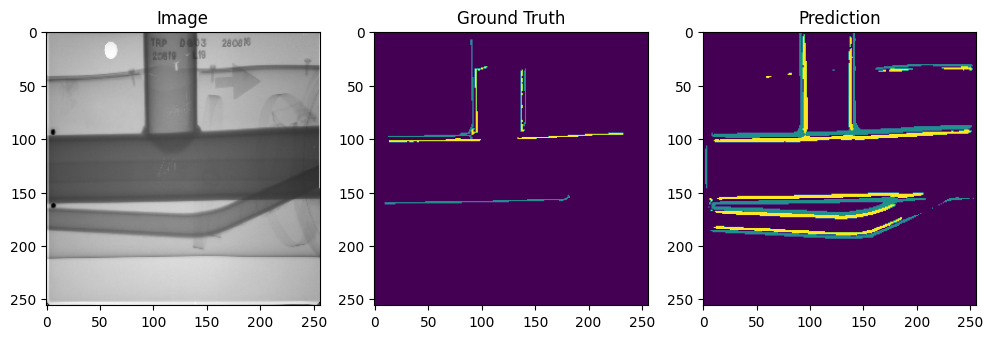

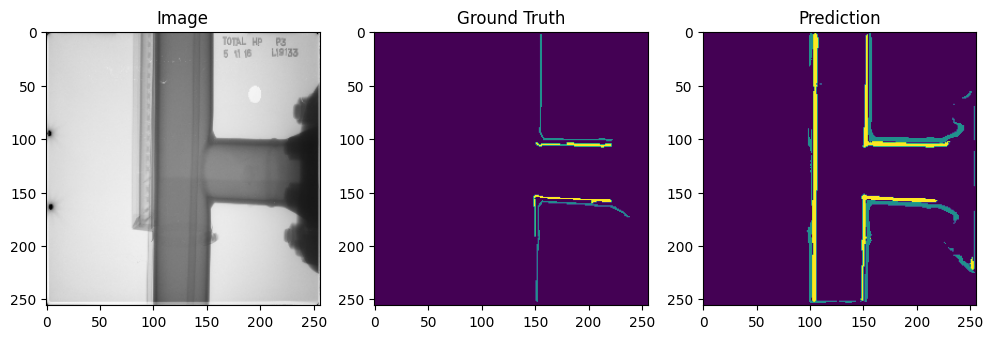

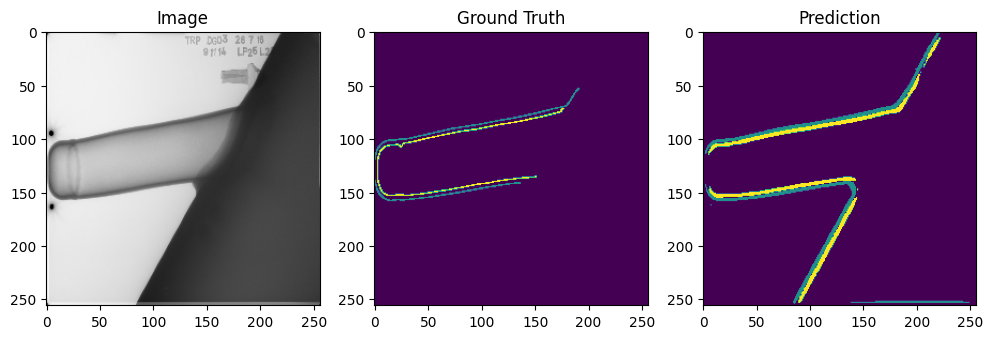

2025-08-21 12:21:15.153471: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
import os
import cv2
import numpy as np
import tensorflow as tf
import torch
from torch.nn import AdaptiveMaxPool2d
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D,
                                     concatenate, BatchNormalization, Activation, Dropout)
from tensorflow.keras.models import Model

# Configuration
IMG_HEIGHT, IMG_WIDTH = 256, 256
NUM_CLASSES = 3
BATCH_SIZE = 8
BUFFER_SIZE = 100
EPOCHS = 120

IMAGE_DIR = '/Users/salah/Desktop/intern/pipe_segmentation/images'
MASK_DIR = '/Users/salah/Desktop/intern/pipe_segmentation/generated_segmentation_masks'

def preprocess_mask(mask):
    mask = np.where(mask == 127, 1, mask)
    mask = np.where(mask == 255, 2, mask)
    mask = np.where(mask < 1, 0, mask)
    return mask.astype(np.uint8)

def adaptive_maxpool_mask_resize(mask_np, output_size=(IMG_HEIGHT, IMG_WIDTH)):
    mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float()
    adaptive_pool = AdaptiveMaxPool2d(output_size)
    pooled_mask = adaptive_pool(mask_tensor)
    pooled_mask_np = pooled_mask.squeeze().byte().numpy()
    return pooled_mask_np

# Load images and masks
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith('.png')])

image_dict = {os.path.splitext(f)[0]: f for f in image_files}
mask_dict = {os.path.splitext(f)[0].replace('_processed_annotated_mask', ''): f for f in mask_files}

X, Y = [], []

for base_name, img_file in image_dict.items():
    if base_name in mask_dict:
        img = cv2.imread(os.path.join(IMAGE_DIR, img_file))
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        mask = cv2.imread(os.path.join(MASK_DIR, mask_dict[base_name]), cv2.IMREAD_GRAYSCALE)
        mask = preprocess_mask(mask)
        mask = adaptive_maxpool_mask_resize(mask, (IMG_HEIGHT, IMG_WIDTH))
        X.append(img)
        Y.append(mask)

X = np.array(X, dtype=np.uint8)
Y = np.array(Y, dtype=np.uint8)

print(f"Total images: {len(X)}")

# One-hot encode masks
Y = tf.keras.utils.to_categorical(Y, num_classes=NUM_CLASSES)

# Train/val/test split
X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.2, random_state=42)

print(f"Train set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

# Class weights calculation
Y_train_labels = np.argmax(Y_train, axis=-1).astype(np.uint8)
all_pixels = Y_train_labels.flatten()
pixel_counts = Counter(all_pixels)
total_pixels = len(all_pixels)

class_weights = {cls: total_pixels / (NUM_CLASSES * count) for cls, count in pixel_counts.items()}
clipped_weights = {k: min(v, 20.0) for k, v in class_weights.items()}
print("Class weights:", clipped_weights)

weights_tensor = tf.constant([clipped_weights[i] for i in range(NUM_CLASSES)], dtype=tf.float32)

# Weighted focal loss using class weights
def weighted_focal_loss(alpha=weights_tensor, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=-1))
    return loss

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    return 1 - tf.reduce_mean((2. * intersection + smooth) / (denominator + smooth))

def combined_loss(y_true, y_pred):
    return 0.5 * weighted_focal_loss()(y_true, y_pred) + 0.5 * dice_loss(y_true, y_pred)

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    return tf.reduce_mean((2. * intersection + smooth) / (denominator + smooth))

# Your U-Net model definition remains the same (not repeated here for brevity)
def conv_block(x, filters, dropout_rate=0.1):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)
    return x

def improved_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    inputs = Input(input_shape)
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D()(c1)
    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D()(c2)
    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D()(c3)
    c4 = conv_block(p3, 512, dropout_rate=0.3)
    u5 = UpSampling2D()(c4)
    u5 = concatenate([u5, c3])
    c5 = conv_block(u5, 256)
    u6 = UpSampling2D()(c5)
    u6 = concatenate([u6, c2])
    c6 = conv_block(u6, 128)
    u7 = UpSampling2D()(c6)
    u7 = concatenate([u7, c1])
    c7 = conv_block(u7, 64)
    outputs = Conv2D(num_classes, 1, activation='softmax')(c7)
    return Model(inputs, outputs)

model = improved_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=combined_loss,
    metrics=[dice_coef]
)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)
]

# Prepare tf.data pipelines (augment function remains the same, not repeated here)
def augment(image, mask):
    image = tf.cast(image, tf.float32)
    mask = tf.cast(mask, tf.float32)  # one-hot mask

    seed = tf.random.uniform([], maxval=10000, dtype=tf.int32)
    image = tf.image.stateless_random_flip_left_right(image, seed=[seed, 0])
    mask = tf.image.stateless_random_flip_left_right(mask, seed=[seed, 0])
    image = tf.image.stateless_random_flip_up_down(image, seed=[seed, 1])
    mask = tf.image.stateless_random_flip_up_down(mask, seed=[seed, 1])
    image = tf.image.stateless_random_brightness(image, max_delta=0.2, seed=[seed, 2])
    image = tf.image.stateless_random_contrast(image, 0.8, 1.2, seed=[seed, 3])
    image = tf.image.stateless_random_saturation(image, 0.8, 1.2, seed=[seed, 4])
    image = tf.image.stateless_random_hue(image, 0.05, seed=[seed, 5])
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)
    return image, mask

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Simple visualization helper to check predictions on val set
def visualize_prediction(model, dataset, num=3):
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds_labels = tf.argmax(preds, axis=-1)
        true_labels = tf.argmax(masks, axis=-1)
        for i in range(num):
            plt.figure(figsize=(12,4))
            plt.subplot(1,3,1)
            plt.title("Image")
            plt.imshow(images[i].numpy().astype(np.uint8))
            plt.subplot(1,3,2)
            plt.title("Ground Truth")
            plt.imshow(true_labels[i].numpy())
            plt.subplot(1,3,3)
            plt.title("Prediction")
            plt.imshow(preds_labels[i].numpy())
            plt.show()

# Call visualization after training
visualize_prediction(model, val_ds, num=3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
Class 0 IoU: 0.9595
Class 1 IoU: 0.3449
Class 2 IoU: 0.3664


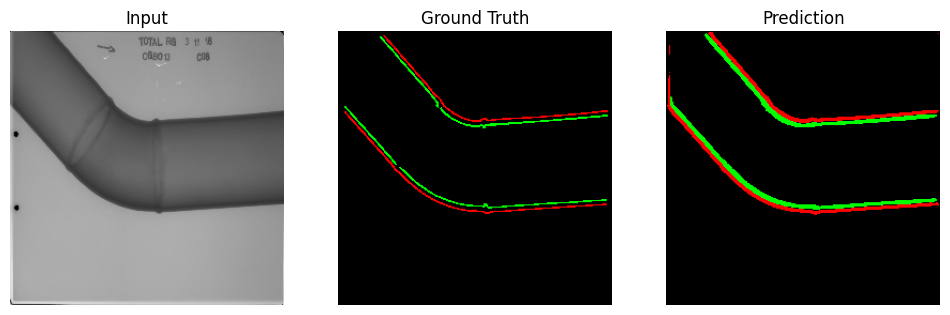

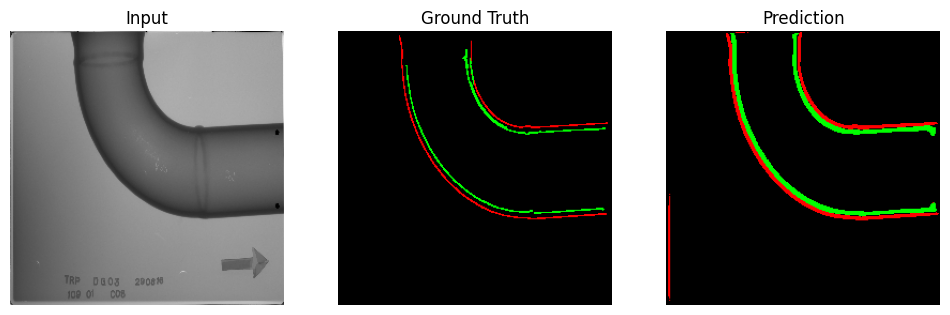

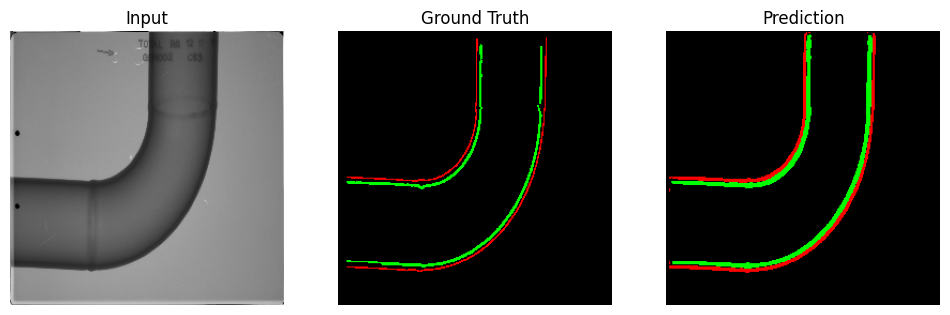

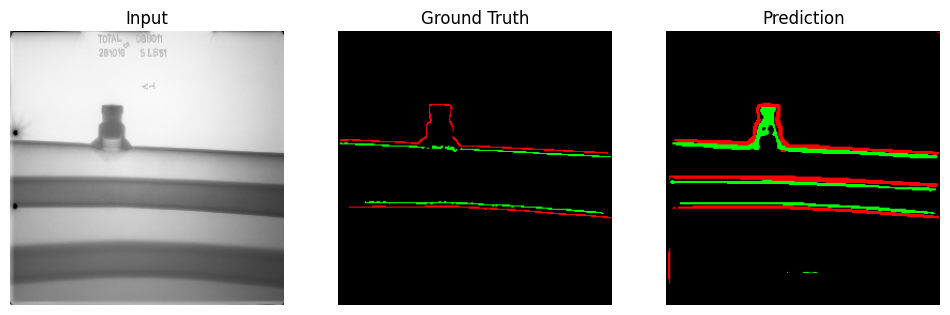

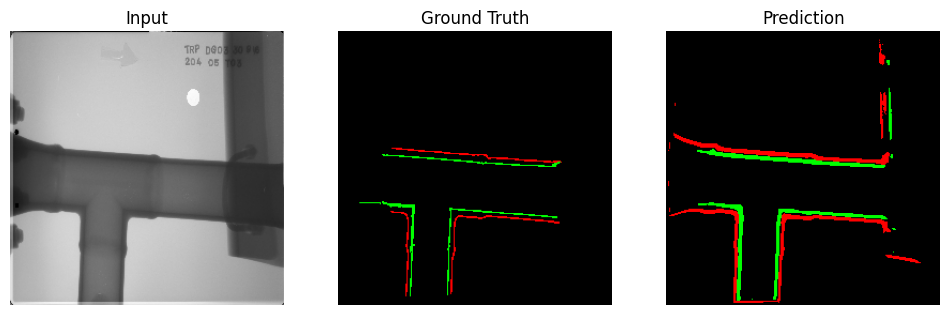

In [4]:
# Prediction & Postprocessingb
def postprocess_mask(pred_mask):
    mask = np.argmax(pred_mask, axis=-1).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask_clean

preds = model.predict(test_ds)
pred_labels = np.argmax(preds, axis=-1)
Y_test_labels = np.argmax(Y_test, axis=-1)

# Evaluation
from sklearn.metrics import jaccard_score

def calculate_iou(y_true, y_pred, class_id):
    y_true_flat = (y_true.flatten() == class_id).astype(np.uint8)
    y_pred_flat = (y_pred.flatten() == class_id).astype(np.uint8)
    return jaccard_score(y_true_flat, y_pred_flat)

for cls in range(NUM_CLASSES):
    iou = calculate_iou(Y_test_labels, pred_labels, cls)
    print(f"Class {cls} IoU: {iou:.4f}")

# Visualization
colors = [[0, 0, 0], [255, 0, 0], [0, 255, 0]]

def colorize_mask(mask):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color in enumerate(colors):
        color_mask[mask == class_id] = color
    return color_mask

for i in range(5):
    img = X_test[i]
    true_mask = np.argmax(Y_test[i], axis=-1)
    pred_mask = pred_labels[i]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Input")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(colorize_mask(true_mask))
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(colorize_mask(pred_mask))
    plt.title("Prediction")
    plt.axis('off')

    plt.show()

In [5]:
model.save('/Users/salah/Desktop/intern/pipe_segmentation/saved_models/pipe_unet_model_last.keras')

In [6]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
📊 Thickness stats for Test_0:
  ✅ Min     = 0.20 mm at (163, 211)
  ✅ Max     = 0.29 mm at (81, 170)
  ✅ Mean    = 0.22 mm
  ✅ Median  = 0.22 mm
  ✅ Std Dev = 0.02 mm


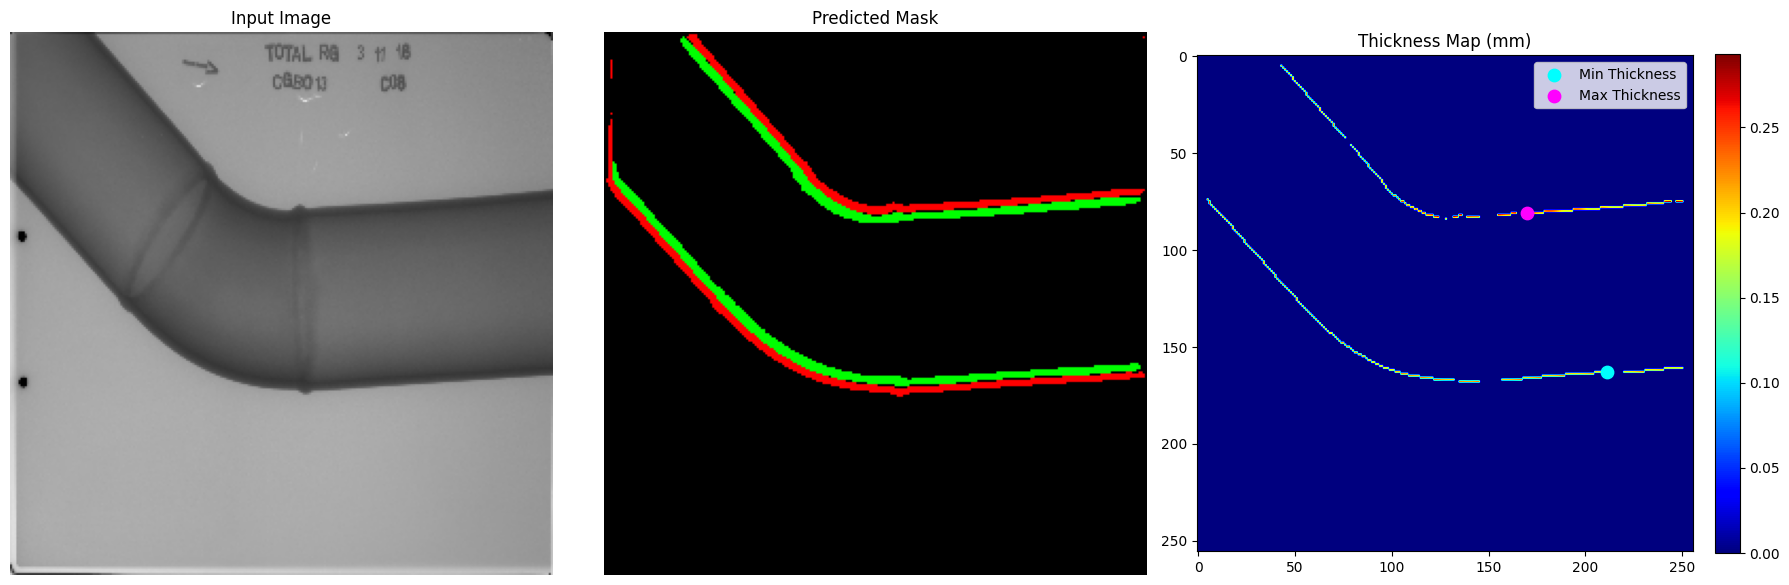

📊 Thickness stats for Test_1:
  ✅ Min     = 0.20 mm at (173, 176)
  ✅ Max     = 0.29 mm at (89, 172)
  ✅ Mean    = 0.22 mm
  ✅ Median  = 0.21 mm
  ✅ Std Dev = 0.02 mm


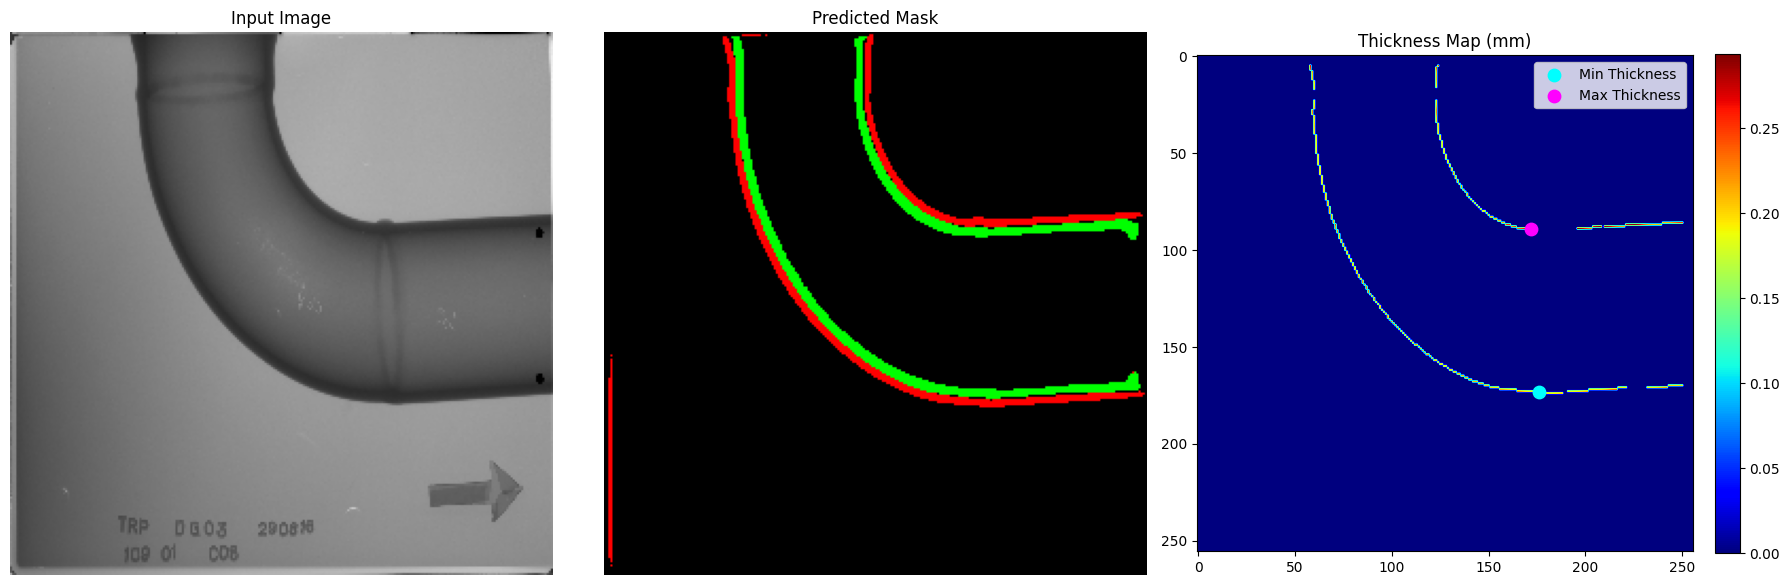

📊 Thickness stats for Test_2:
  ✅ Min     = 0.18 mm at (122, 112)
  ✅ Max     = 0.29 mm at (138, 40)
  ✅ Mean    = 0.21 mm
  ✅ Median  = 0.20 mm
  ✅ Std Dev = 0.02 mm


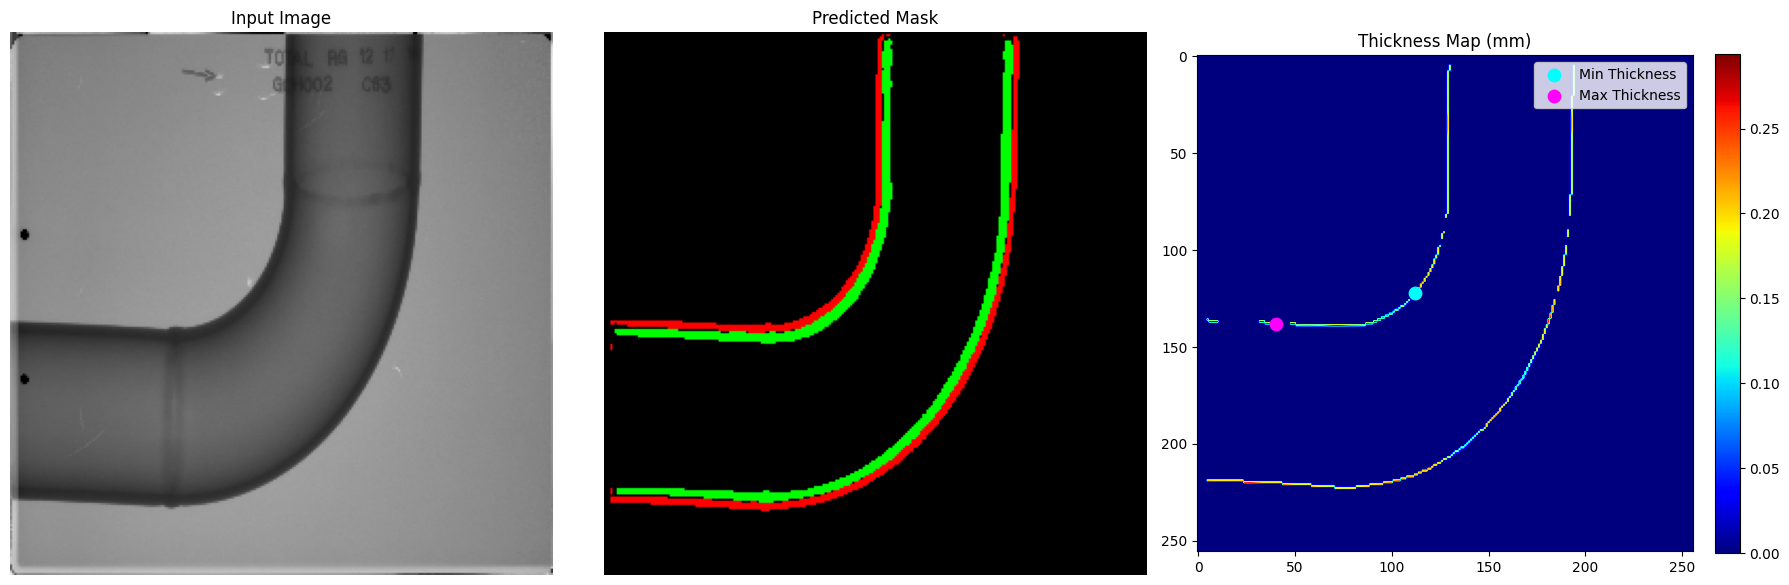

📊 Thickness stats for Test_3:
  ✅ Min     = 0.20 mm at (163, 27)
  ✅ Max     = 0.31 mm at (143, 221)
  ✅ Mean    = 0.24 mm
  ✅ Median  = 0.22 mm
  ✅ Std Dev = 0.04 mm


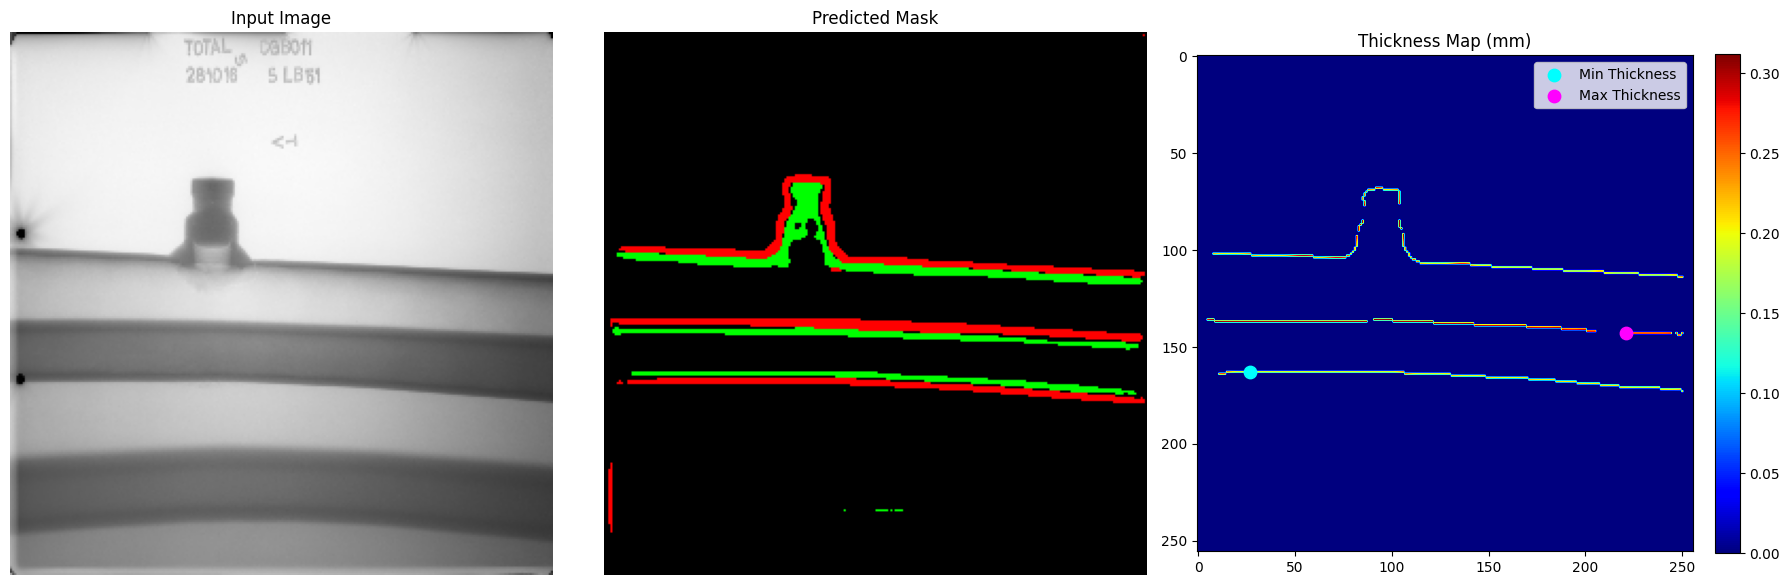

📊 Thickness stats for Test_4:
  ✅ Min     = 0.20 mm at (237, 64)
  ✅ Max     = 2.96 mm at (212, 221)
  ✅ Mean    = 0.64 mm
  ✅ Median  = 0.32 mm
  ✅ Std Dev = 0.69 mm


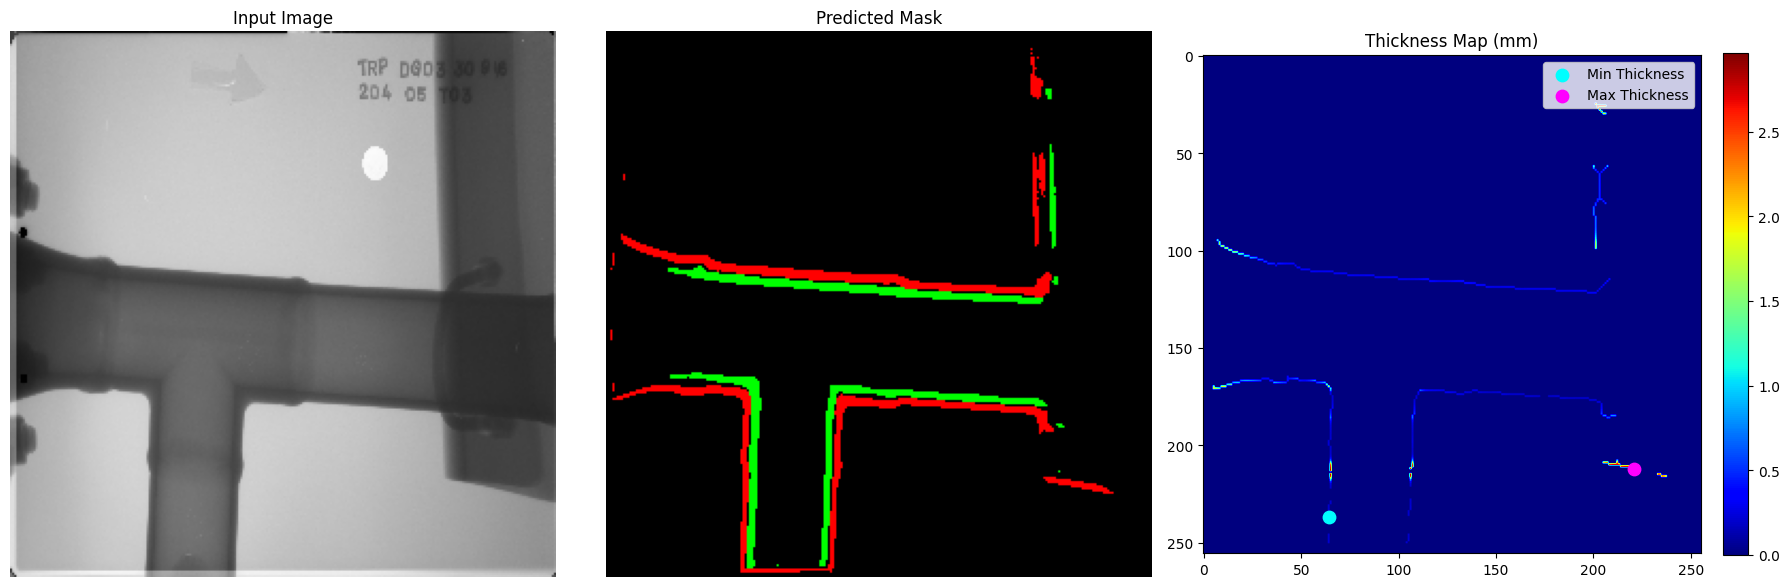

In [7]:
from scipy.ndimage import distance_transform_edt, gaussian_filter1d
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# ---------------------
# 1️⃣ Clean mask
# ---------------------
def clean_pipe_mask(mask, min_component_area=200, bridge_kernel=5):
    """
    Cleans a 2-class mask (outer edge=1, inner edge=2) while keeping
    *all* relevant connected components above a minimum area.

    Parameters
    ----------
    mask : np.ndarray
        Input labeled mask.
    min_component_area : int
        Minimum pixel area for a component to be kept.
    bridge_kernel : int
        Closing kernel size to bridge small gaps.
    """
    mask = mask.copy().astype(np.uint8)

    # Morphological closing to reconnect small breaks
    if bridge_kernel and bridge_kernel > 1:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (bridge_kernel, bridge_kernel))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    cleaned = np.zeros_like(mask)

    for cls in [1, 2]:  # Outer = 1, Inner = 2
        binary = (mask == cls).astype(np.uint8)
        if np.count_nonzero(binary) == 0:
            continue

        # Connected components
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

        keep_labels = []
        for label_id in range(1, num_labels):  # skip background
            area = stats[label_id, cv2.CC_STAT_AREA]
            if area >= min_component_area:
                keep_labels.append(label_id)

        if keep_labels:
            comp_mask = np.isin(labels, keep_labels).astype(np.uint8)
            cleaned[comp_mask == 1] = cls

    return cleaned


# ---------------------
# 2️⃣ Measure thickness
# ---------------------
def measure_pipe_wall_thickness(mask, original_shape=None, resized_shape=None,
                                visualize=False, image_name=None,
                                min_wall_area=50, pixel_spacing=1.0,
                                border_margin=5):  # NEW: margin to ignore edges
    if resized_shape is None:
        resized_shape = mask.shape[:2]

    mask = clean_pipe_mask(mask, min_component_area=min_wall_area)

    outer_edge = (mask == 1).astype(np.uint8)
    inner_edge = (mask == 2).astype(np.uint8)
    if np.sum(outer_edge) == 0 or np.sum(inner_edge) == 0:
        raise ValueError("Missing outer or inner edge in mask")

    # Safe contour filling
    def fill_contour(edge_mask):
        filled = np.zeros_like(edge_mask, dtype=np.uint8)
        contours, _ = cv2.findContours(edge_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) > 0:
            cv2.drawContours(filled, contours, -1, 1, thickness=-1)
        return filled

    outer_filled = fill_contour(outer_edge)
    inner_filled = fill_contour(inner_edge)
    pipe_wall_mask = cv2.bitwise_and(outer_filled, cv2.bitwise_not(inner_filled))

    # Remove small components
    num_labels, labels, stats_cc, _ = cv2.connectedComponentsWithStats(pipe_wall_mask, connectivity=8)
    for i in range(1, num_labels):
        if stats_cc[i, cv2.CC_STAT_AREA] < min_wall_area:
            pipe_wall_mask[labels == i] = 0

    if np.sum(pipe_wall_mask) == 0:
        raise ValueError("No valid pipe wall found after filtering")

    # Medial axis & distance transforms
    medial_axis = skeletonize(pipe_wall_mask).astype(np.uint8)
    if np.sum(medial_axis) == 0:
        raise ValueError("No medial axis found")
    dist_to_outer = distance_transform_edt(1 - outer_edge)
    dist_to_inner = distance_transform_edt(1 - inner_edge)

    medial_points = np.where(medial_axis == 1)
    thickness_values = dist_to_outer[medial_points] + dist_to_inner[medial_points]

    # FILTER POINTS NEAR IMAGE EDGES
    h, w = mask.shape[:2]
    yy, xx = medial_points
    valid_mask = (yy >= border_margin) & (yy < h - border_margin) & \
                 (xx >= border_margin) & (xx < w - border_margin)
    medial_points = (yy[valid_mask], xx[valid_mask])
    thickness_values = thickness_values[valid_mask]

    if len(thickness_values) > 3:
        thickness_values = gaussian_filter1d(thickness_values, sigma=3)

    # Scale to original image and mm
    if original_shape is not None:
        orig_h, orig_w = original_shape
        resized_h, resized_w = resized_shape
        scale = (orig_h / resized_h + orig_w / resized_w) / 2
    else:
        scale = 1.0
    thickness_values_mm = thickness_values * scale * pixel_spacing

    # Filter outliers 5-95 percentile
    if thickness_values_mm.size > 0:
        q_low, q_high = np.percentile(thickness_values_mm, [5, 95])
        valid_idx = (thickness_values_mm >= q_low) & (thickness_values_mm <= q_high)
        tv_mm_filtered = thickness_values_mm[valid_idx]
        medial_points_filtered = (medial_points[0][valid_idx], medial_points[1][valid_idx])
    else:
        tv_mm_filtered = thickness_values_mm
        medial_points_filtered = medial_points

    stats = {
        'thickness_values_mm': tv_mm_filtered,
        'medial_points': medial_points_filtered,
        'scale_factor': scale
    }

    # Visualization
    if visualize:
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))

        axs[0].imshow(mask, cmap='gray')
        axs[0].set_title("Cleaned Mask")
        axs[0].axis('off')

        axs[1].imshow(pipe_wall_mask, cmap='gray')
        axs[1].scatter(medial_points_filtered[1], medial_points_filtered[0], s=1, c='red')
        axs[1].set_title("Pipe Wall + Medial Axis")
        axs[1].axis('off')

        thickness_img_mm = np.zeros_like(mask, dtype=np.float32)
        thickness_img_mm[medial_points_filtered] = tv_mm_filtered
        im = axs[2].imshow(thickness_img_mm, cmap='jet')
        axs[2].set_title("Thickness Map (mm)")
        axs[2].axis('off')
        plt.colorbar(im, ax=axs[2], label='Thickness (mm)')

        axs[3].hist(tv_mm_filtered, bins=30, color='gray')
        axs[3].set_title("Filtered Thickness Histogram (mm)")
        axs[3].set_xlabel("Thickness (mm)")
        axs[3].grid(True)

        plt.suptitle(f"Thickness Analysis - {image_name}\nScale: {scale:.3f}, Pixel Spacing: {pixel_spacing} mm/px", fontsize=16)
        plt.tight_layout()
        plt.show()

    return stats

# ---------------------
# 3️⃣ Color mask
# ---------------------
def colorize_mask(mask):
    h, w = mask.shape
    colored = np.zeros((h, w, 3), dtype=np.uint8)
    colored[mask == 1] = [255, 0, 0]   # Red for outer edge
    colored[mask == 2] = [0, 255, 0]   # Green for inner edge
    return colored

# ---------------------
# 4️⃣ Visualize prediction with thickness
# ---------------------
def visualize_prediction_with_thickness(image, pred_mask, image_name=None, pixel_spacing=1.0):
    stats = None
    try:
        stats = measure_pipe_wall_thickness(
            pred_mask, visualize=False, image_name=image_name, pixel_spacing=pixel_spacing
        )
    except Exception as e:
        print(f"⚠ Skipping thickness measurement for {image_name}: {e}")

    color_pred_mask = colorize_mask(pred_mask)

    plt.figure(figsize=(18, 6))

    # Input image
    plt.subplot(1, 3, 1)
    plt.title('Input Image')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # Predicted mask
    plt.subplot(1, 3, 2)
    plt.title('Predicted Mask')
    plt.imshow(color_pred_mask)
    plt.axis('off')

    # Thickness map
    plt.subplot(1, 3, 3)
    if stats is not None and stats['thickness_values_mm'].size > 0:
        thickness_map = np.zeros_like(pred_mask, dtype=np.float32)
        yy, xx = stats['medial_points']
        tv = stats['thickness_values_mm']

        min_len = min(len(yy), len(tv))
        thickness_map[yy[:min_len], xx[:min_len]] = tv[:min_len]

        im = plt.imshow(thickness_map, cmap='jet')
        plt.title('Thickness Map (mm)')
        plt.colorbar(im, fraction=0.046, pad=0.04)

        min_idx, max_idx = np.argmin(tv[:min_len]), np.argmax(tv[:min_len])
        min_coord, max_coord = (yy[min_idx], xx[min_idx]), (yy[max_idx], xx[max_idx])

        # Print stats
        print(f"📊 Thickness stats for {image_name}:")
        print(f"  ✅ Min     = {np.min(tv[:min_len]):.2f} mm at {min_coord}")
        print(f"  ✅ Max     = {np.max(tv[:min_len]):.2f} mm at {max_coord}")
        print(f"  ✅ Mean    = {np.mean(tv[:min_len]):.2f} mm")
        print(f"  ✅ Median  = {np.median(tv[:min_len]):.2f} mm")
        print(f"  ✅ Std Dev = {np.std(tv[:min_len]):.2f} mm")

        # Mark min/max points
        plt.scatter([min_coord[1]], [min_coord[0]], c='cyan', s=80, marker='o', label='Min Thickness')
        plt.scatter([max_coord[1]], [max_coord[0]], c='magenta', s=80, marker='o', label='Max Thickness')
        plt.legend(loc='upper right')

    else:
        plt.text(0.5, 0.5, 'Thickness data unavailable',
                 horizontalalignment='center', verticalalignment='center',
                 fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# ---------------------
# 5️⃣ Example usage
# ---------------------
preds = model.predict(X_test)
pred_labels = np.argmax(preds, axis=-1)

for i in range(min(5, len(X_test))):
    visualize_prediction_with_thickness(
        X_test[i], pred_labels[i], image_name=f"Test_{i}", pixel_spacing=0.1
    )


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
Segment 1: Min=0.20mm at (79,203), Max=0.30mm at (82,149), Mean=0.24mm
Saved 195 points to Test_0_segment_1_points.csv
Segment 2: Min=0.20mm at (163,211), Max=0.23mm at (163,229), Mean=0.21mm
Saved 241 points to Test_0_segment_2_points.csv


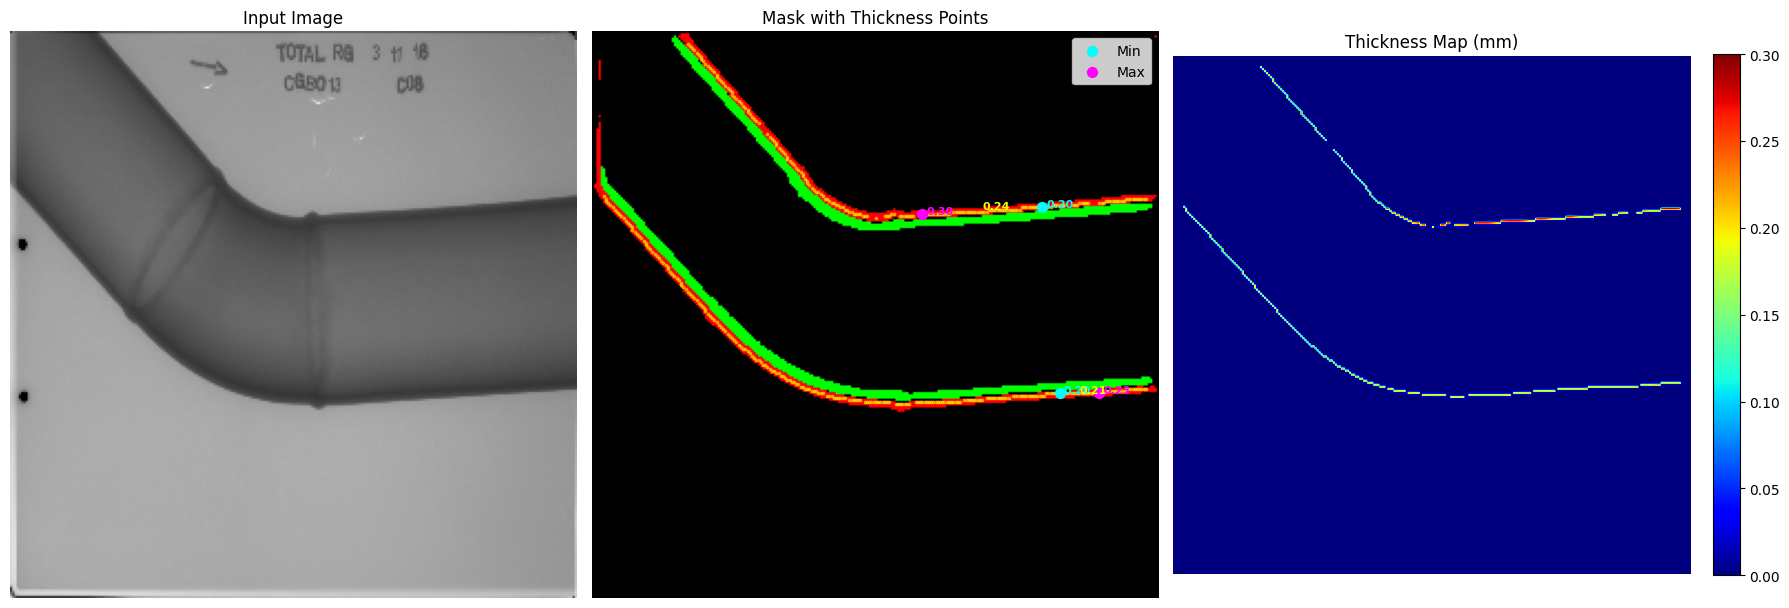

Segment 1: Min=0.20mm at (14,123), Max=0.30mm at (89,177), Mean=0.23mm
Saved 170 points to Test_1_segment_1_points.csv
Segment 2: Min=0.20mm at (171,221), Max=0.24mm at (171,242), Mean=0.21mm
Saved 270 points to Test_1_segment_2_points.csv


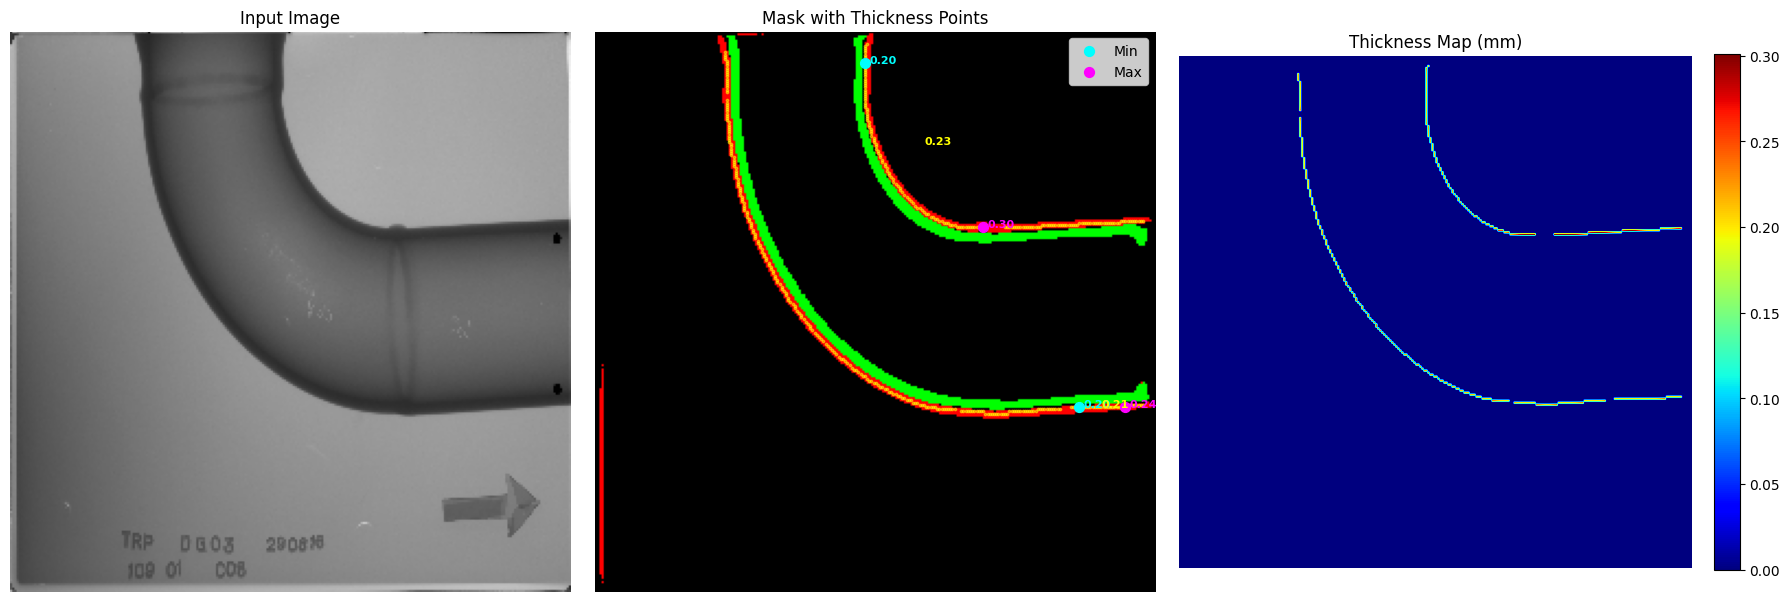

Segment 1: Min=0.20mm at (17,129), Max=0.30mm at (137,14), Mean=0.24mm
Saved 224 points to Test_2_segment_1_points.csv
Segment 2: Min=0.16mm at (121,186), Max=0.24mm at (220,99), Mean=0.20mm
Saved 298 points to Test_2_segment_2_points.csv


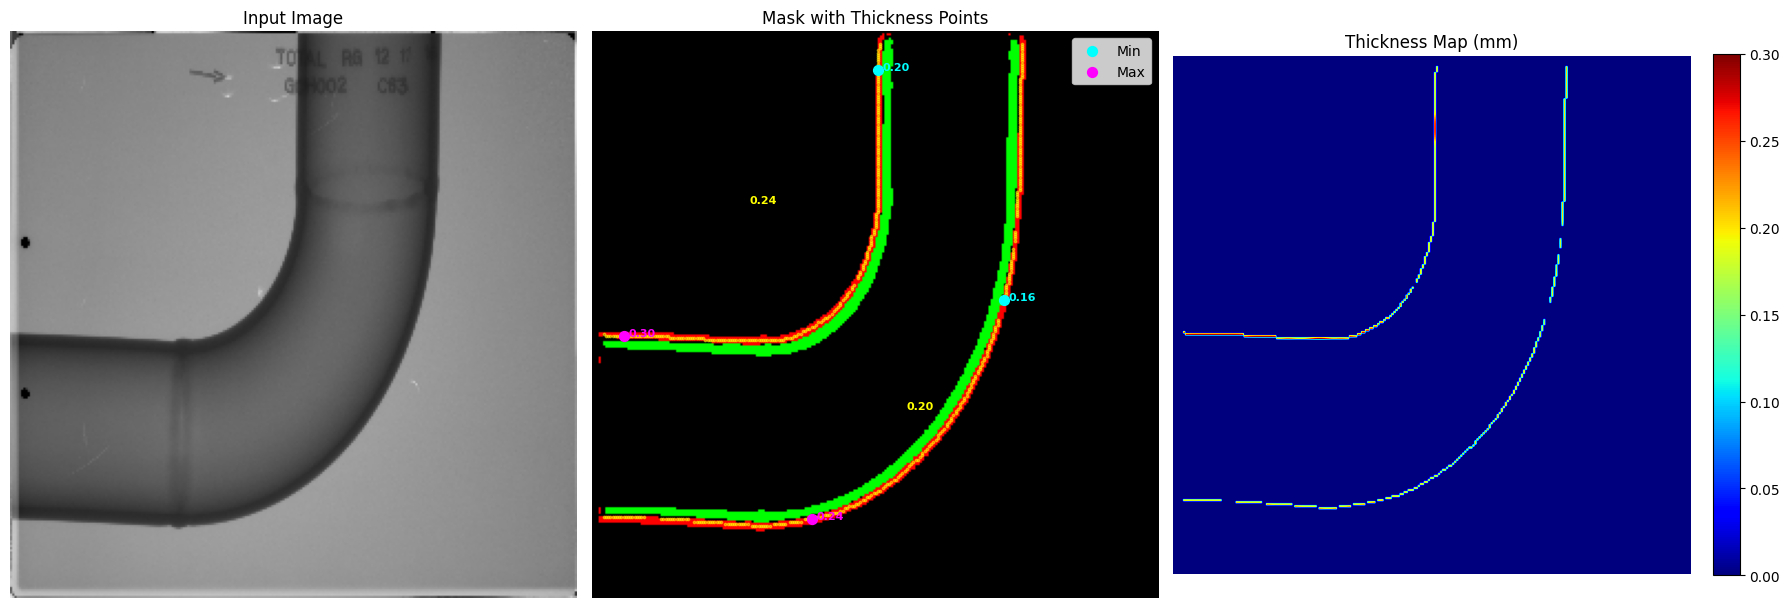

Segment 1: Min=0.20mm at (102,18), Max=0.32mm at (92,106), Mean=0.23mm
Saved 268 points to Test_3_segment_1_points.csv
Segment 2: Min=0.30mm at (137,17), Max=0.33mm at (136,8), Mean=0.30mm
Saved 233 points to Test_3_segment_2_points.csv
Segment 3: Min=0.20mm at (163,15), Max=0.22mm at (172,239), Mean=0.20mm
Saved 228 points to Test_3_segment_3_points.csv


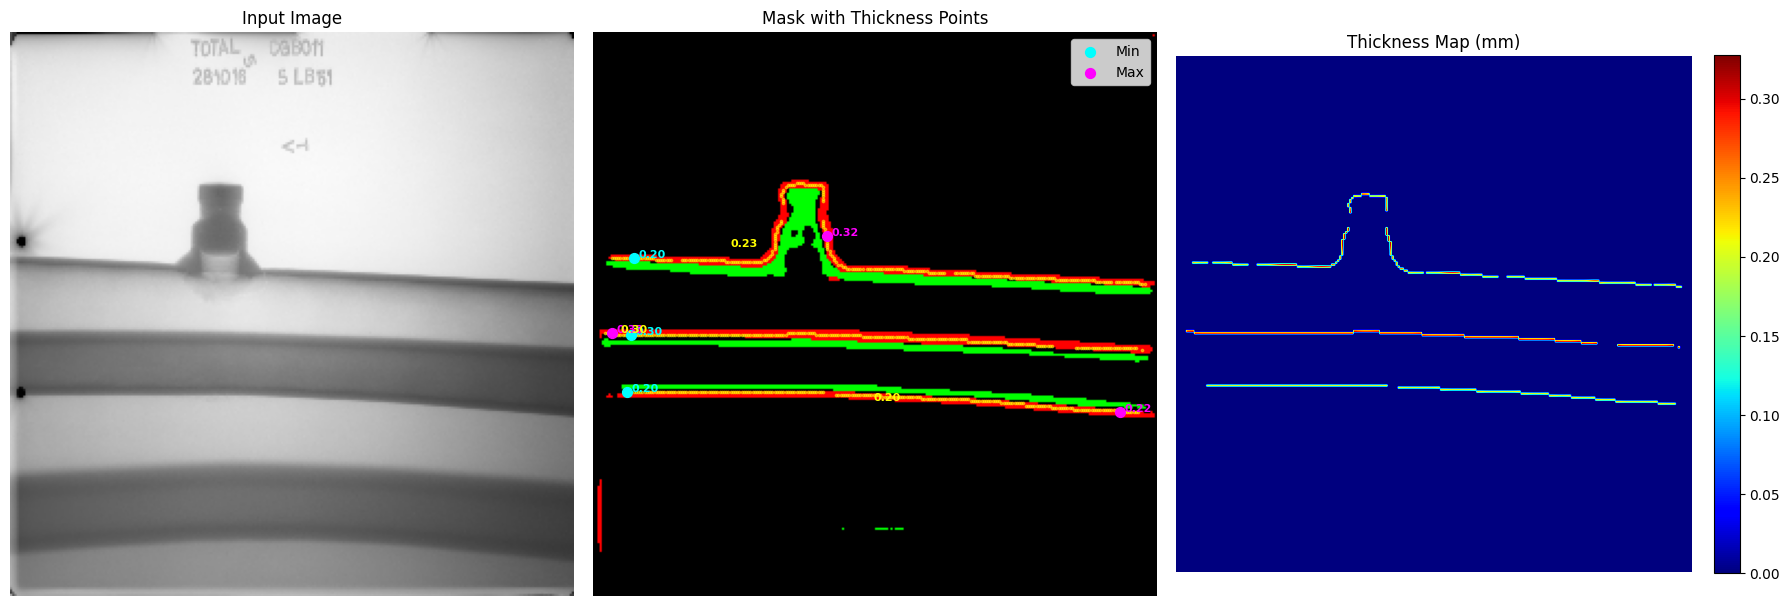

Segment 1: Min=2.47mm at (29,204), Max=4.38mm at (10,199), Mean=3.41mm
Saved 27 points to Test_4_segment_1_points.csv
Segment 2: Min=0.48mm at (60,204), Max=0.77mm at (81,200), Mean=0.60mm
Saved 45 points to Test_4_segment_2_points.csv
Segment 3: Min=0.30mm at (121,185), Max=1.54mm at (101,17), Mean=0.38mm
Saved 181 points to Test_4_segment_3_points.csv
Segment 4: Min=0.20mm at (175,175), Max=0.99mm at (168,15), Mean=0.31mm
Saved 310 points to Test_4_segment_4_points.csv
Segment 5: Min=3.41mm at (209,206), Max=4.97mm at (216,235), Mean=4.03mm
Saved 31 points to Test_4_segment_5_points.csv


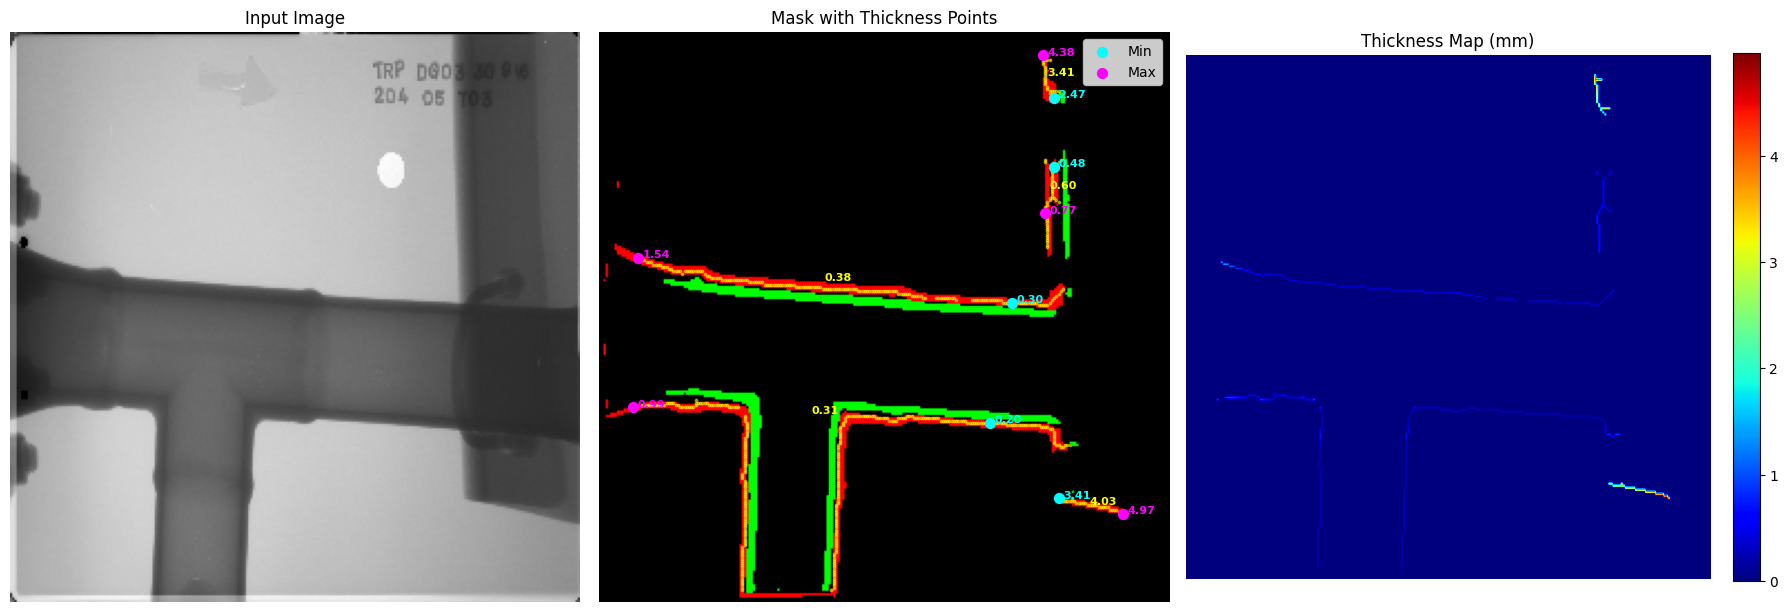

In [8]:
from scipy.ndimage import distance_transform_edt, gaussian_filter1d
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# ---------------------
# 1️⃣ Clean mask with gap bridging and noise removal
# ---------------------
def clean_pipe_mask(mask, min_component_area=200, bridge_kernel=5):
    mask = mask.copy().astype(np.uint8)
    if bridge_kernel > 1:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (bridge_kernel, bridge_kernel))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    cleaned = np.zeros_like(mask)
    for cls in [1, 2]:  # Outer=1, Inner=2
        binary = (mask == cls).astype(np.uint8)
        if np.count_nonzero(binary) == 0:
            continue
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
        keep_labels = [label_id for label_id in range(1, num_labels)
                       if stats[label_id, cv2.CC_STAT_AREA] >= min_component_area]
        if keep_labels:
            comp_mask = np.isin(labels, keep_labels).astype(np.uint8)
            cleaned[comp_mask == 1] = cls
    return cleaned

# ---------------------
# 2️⃣ Measure thickness per segment with percentile-based filtering
# ---------------------
def measure_pipe_wall_thickness(mask, min_wall_area=50, pixel_spacing=1.0,
                                border_margin=5, min_length=10, perc_low=5, perc_high=95):
    mask = clean_pipe_mask(mask, min_component_area=min_wall_area)
    outer_edge = (mask == 1).astype(np.uint8)
    inner_edge = (mask == 2).astype(np.uint8)
    if np.sum(outer_edge) == 0 or np.sum(inner_edge) == 0:
        raise ValueError("Missing outer or inner edge in mask")

    # Fill contours
    def fill_contour(edge_mask):
        filled = np.zeros_like(edge_mask, dtype=np.uint8)
        contours, _ = cv2.findContours(edge_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            cv2.drawContours(filled, contours, -1, 1, thickness=-1)
        return filled

    outer_filled = fill_contour(outer_edge)
    inner_filled = fill_contour(inner_edge)
    pipe_mask = cv2.bitwise_and(outer_filled, cv2.bitwise_not(inner_filled))

    # Remove small components
    num_labels, labels, stats_cc, _ = cv2.connectedComponentsWithStats(pipe_mask, connectivity=8)
    for i in range(1, num_labels):
        if stats_cc[i, cv2.CC_STAT_AREA] < min_wall_area:
            pipe_mask[labels == i] = 0
    if np.sum(pipe_mask) == 0:
        raise ValueError("No valid pipe wall after filtering")

    # Medial axis
    medial_axis = skeletonize(pipe_mask).astype(np.uint8)
    if np.sum(medial_axis) == 0:
        raise ValueError("No medial axis found")

    dist_to_outer = distance_transform_edt(1 - outer_edge)
    dist_to_inner = distance_transform_edt(1 - inner_edge)

    # Analyze segments
    segment_labels = label(pipe_mask)
    segments_stats = {}
    for region in regionprops(segment_labels):
        yy, xx = region.coords[:,0], region.coords[:,1]

        # Ignore border points
        valid = (yy >= border_margin) & (yy < mask.shape[0]-border_margin) & \
                (xx >= border_margin) & (xx < mask.shape[1]-border_margin)
        yy, xx = yy[valid], xx[valid]
        if len(yy) < min_length:
            continue

        # Medial axis points
        medial_mask = medial_axis[yy, xx] > 0
        yy_med, xx_med = yy[medial_mask], xx[medial_mask]
        if len(yy_med) < min_length:
            continue

        thickness = (dist_to_outer[yy_med, xx_med] + dist_to_inner[yy_med, xx_med]) * pixel_spacing
        if len(thickness) > 3:
            thickness = gaussian_filter1d(thickness, sigma=2)

        # Percentile-based outlier removal
        low, high = np.percentile(thickness, [perc_low, perc_high])
        valid_th = (thickness >= low) & (thickness <= high)
        thickness = thickness[valid_th]
        yy_med, xx_med = yy_med[valid_th], xx_med[valid_th]
        if len(thickness) == 0:
            continue

        min_idx, max_idx = np.argmin(thickness), np.argmax(thickness)
        segments_stats[region.label] = {
            'coords': (yy_med, xx_med),
            'thickness_mm': thickness,
            'min': (thickness[min_idx], (yy_med[min_idx], xx_med[min_idx])),
            'max': (thickness[max_idx], (yy_med[max_idx], xx_med[max_idx])),
            'mean': np.mean(thickness),
            'all_points': np.column_stack([yy_med, xx_med, thickness])
        }

    return segments_stats, pipe_mask

# ---------------------
# 3️⃣ Color mask
# ---------------------
def colorize_mask(mask):
    h, w = mask.shape
    colored = np.zeros((h, w, 3), dtype=np.uint8)
    colored[mask==1] = [255, 0, 0]   # Outer
    colored[mask==2] = [0, 255, 0]   # Inner
    return colored

# ---------------------
# 4️⃣ Visualization with all points
# ---------------------
def visualize_prediction_with_thickness(image, pred_mask, pixel_spacing=1.0, image_name=None):
    segments_stats, pipe_mask = measure_pipe_wall_thickness(pred_mask, pixel_spacing=pixel_spacing)

    color_mask = colorize_mask(pred_mask)
    thickness_map = np.zeros_like(pred_mask, dtype=np.float32)

    plt.figure(figsize=(18,6))

    # Input image
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Input Image")
    plt.axis('off')

    # Mask with all medial axis points
    plt.subplot(1,3,2)
    plt.imshow(color_mask)
    plt.title("Mask with Thickness Points")
    for seg_id, seg in segments_stats.items():
        yy, xx = seg['coords']
        thickness_map[yy, xx] = seg['thickness_mm']

        # Show all points
        plt.scatter(xx, yy, c='yellow', s=3, alpha=0.5)

        # Min, Max, Mean
        min_val, (my, mx) = seg['min']
        max_val, (MY, MX) = seg['max']
        mean_val = seg['mean']
        plt.scatter([mx], [my], c='cyan', s=50, label='Min' if seg_id==1 else "")
        plt.scatter([MX], [MY], c='magenta', s=50, label='Max' if seg_id==1 else "")
        plt.text(mx+2, my, f"{min_val:.2f}", color='cyan', fontsize=8, weight='bold')
        plt.text(MX+2, MY, f"{max_val:.2f}", color='magenta', fontsize=8, weight='bold')
        plt.text((mx+MX)//2, (my+MY)//2, f"{mean_val:.2f}", color='yellow', fontsize=8, weight='bold')

        print(f"Segment {seg_id}: Min={min_val:.2f}mm at ({my},{mx}), "
              f"Max={max_val:.2f}mm at ({MY},{MX}), Mean={mean_val:.2f}mm")

        # Save CSV of all points
        if image_name:
            csv_path = f"{image_name}_segment_{seg_id}_points.csv"
            np.savetxt(csv_path, seg['all_points'], delimiter=",",
                       header="y,x,thickness_mm", comments='', fmt="%.3f")
            print(f"Saved {len(seg['all_points'])} points to {csv_path}")

    plt.axis('off')
    plt.legend(loc='upper right')

    # Thickness map
    plt.subplot(1,3,3)
    im = plt.imshow(thickness_map, cmap='jet')
    plt.title("Thickness Map (mm)")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# ---------------------
# 5️⃣ Example usage
# ---------------------
preds = model.predict(X_test)
pred_labels = np.argmax(preds, axis=-1)

for i in range(min(5, len(X_test))):
    visualize_prediction_with_thickness(
        X_test[i], pred_labels[i], pixel_spacing=0.1, image_name=f"Test_{i}"
    )


Total images: 75
Train set: 53 samples
Validation set: 14 samples
Test set: 8 samples
Class weights: {0: 0.34096151239160677, 1: 20.0, 2: 20.0}
Epoch 1/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - dice_coef: 0.1622 - loss: 0.7271 - val_dice_coef: 0.1273 - val_loss: 0.6873 - learning_rate: 5.0000e-05
Epoch 2/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - dice_coef: 0.1903 - loss: 0.5958 - val_dice_coef: 0.0981 - val_loss: 0.8151 - learning_rate: 5.0000e-05
Epoch 3/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - dice_coef: 0.2138 - loss: 0.5381 - val_dice_coef: 0.0931 - val_loss: 0.9282 - learning_rate: 5.0000e-05
Epoch 4/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - dice_coef: 0.2359 - loss: 0.5068 - val_dice_coef: 0.1103 - val_loss: 0.9183 - learning_rate: 5.0000e-05
Epoch 5/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - dice_coef: 0.2515 - loss: 0.4773 - val_dice_coef: 0.1356 - val_loss: 0.8270 - learning_rate: 5.0000e-05
Epoch 6/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - dice_coef: 0.2682 - loss: 0.45

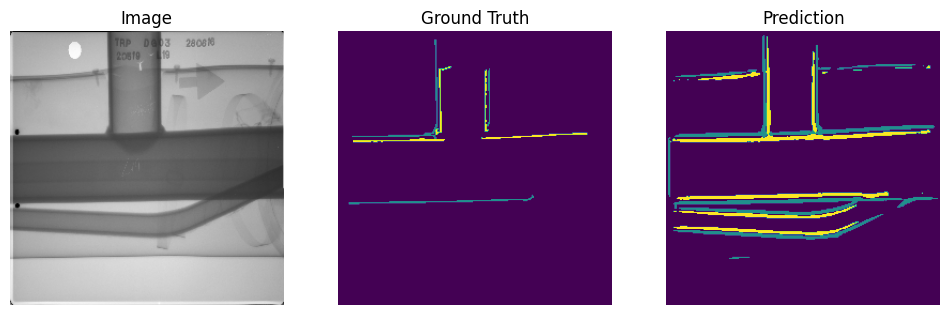

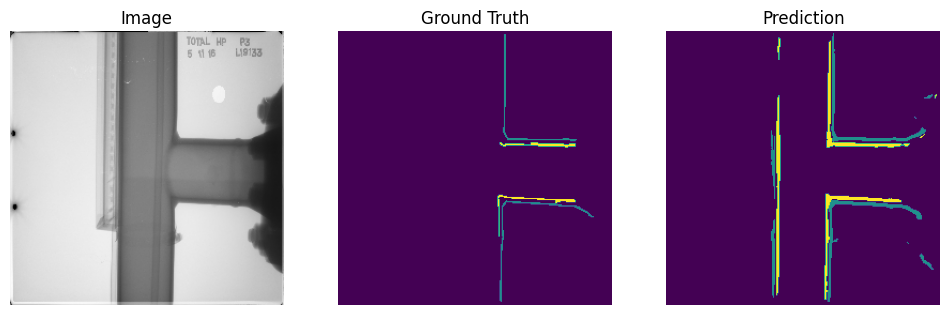

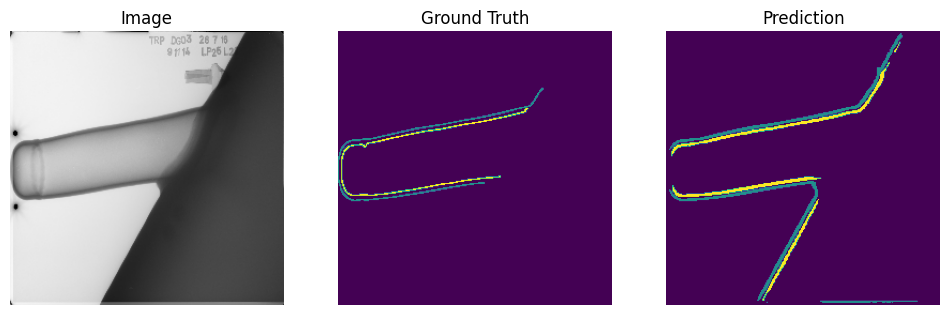

2025-08-21 13:08:57.334114: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
import os
import cv2
import numpy as np
import tensorflow as tf
import torch
from torch.nn import AdaptiveMaxPool2d
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D,
                                     concatenate, BatchNormalization, Activation, Dropout,
                                     Multiply, Add)
from tensorflow.keras.models import Model

# -----------------------------
# Configuration
# -----------------------------
IMG_HEIGHT, IMG_WIDTH = 256, 256
NUM_CLASSES = 3
BATCH_SIZE = 8
BUFFER_SIZE = 100
EPOCHS = 120

IMAGE_DIR = '/Users/salah/Desktop/intern/pipe_segmentation/images'
MASK_DIR = '/Users/salah/Desktop/intern/pipe_segmentation/generated_segmentation_masks'

# -----------------------------
# Data loading & preprocessing
# -----------------------------
def preprocess_mask(mask):
    # Map grayscale mask: 0/127/255 -> 0/1/2 (background/outer/inner as you defined earlier)
    mask = np.where(mask == 127, 1, mask)
    mask = np.where(mask == 255, 2, mask)
    mask = np.where(mask < 1, 0, mask)
    return mask.astype(np.uint8)

def adaptive_maxpool_mask_resize(mask_np, output_size=(IMG_HEIGHT, IMG_WIDTH)):
    # Torch adaptive max pool to preserve labels better than interpolation
    mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float()
    adaptive_pool = AdaptiveMaxPool2d(output_size)
    pooled_mask = adaptive_pool(mask_tensor)
    pooled_mask_np = pooled_mask.squeeze().byte().numpy()
    return pooled_mask_np

# Load images and masks
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith('.png')])

# Match images to masks by basename (strip your suffix from mask filenames)
image_dict = {os.path.splitext(f)[0]: f for f in image_files}
mask_dict = {os.path.splitext(f)[0].replace('_processed_annotated_mask', ''): f for f in mask_files}

X, Y = [], []

for base_name, img_file in image_dict.items():
    if base_name in mask_dict:
        img = cv2.imread(os.path.join(IMAGE_DIR, img_file))
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        mask = cv2.imread(os.path.join(MASK_DIR, mask_dict[base_name]), cv2.IMREAD_GRAYSCALE)
        mask = preprocess_mask(mask)
        mask = adaptive_maxpool_mask_resize(mask, (IMG_HEIGHT, IMG_WIDTH))
        X.append(img)
        Y.append(mask)

X = np.array(X, dtype=np.uint8)
Y = np.array(Y, dtype=np.uint8)

print(f"Total images: {len(X)}")

# One-hot encode masks
Y = tf.keras.utils.to_categorical(Y, num_classes=NUM_CLASSES)

# -----------------------------
# Train/val/test split
# -----------------------------
X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.2, random_state=42)

print(f"Train set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

# -----------------------------
# Class weights (pixel-level)
# -----------------------------
Y_train_labels = np.argmax(Y_train, axis=-1).astype(np.uint8)
all_pixels = Y_train_labels.flatten()
pixel_counts = Counter(all_pixels)
total_pixels = len(all_pixels)

class_weights = {cls: total_pixels / (NUM_CLASSES * count) for cls, count in pixel_counts.items()}
clipped_weights = {k: min(v, 20.0) for k, v in class_weights.items()}
print("Class weights:", clipped_weights)

weights_tensor = tf.constant([clipped_weights[i] for i in range(NUM_CLASSES)], dtype=tf.float32)

# -----------------------------
# Losses & metric
# -----------------------------
def weighted_focal_loss(alpha=weights_tensor, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=-1))
    return loss

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    return 1 - tf.reduce_mean((2. * intersection + smooth) / (denominator + smooth))

def combined_loss(y_true, y_pred):
    return 0.5 * weighted_focal_loss()(y_true, y_pred) + 0.5 * dice_loss(y_true, y_pred)

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    return tf.reduce_mean((2. * intersection + smooth) / (denominator + smooth))

# -----------------------------
# Building blocks
# -----------------------------
def conv_block(x, filters, dropout_rate=0.1):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    if dropout_rate and dropout_rate > 0:
        x = Dropout(dropout_rate)(x)
    return x

def attention_block(x, g, inter_channels):
    """
    Attention gate:
    x: skip features from encoder
    g: gating signal from decoder (upsampled)
    """
    theta_x = Conv2D(inter_channels, (1, 1), padding='same')(x)
    phi_g   = Conv2D(inter_channels, (1, 1), padding='same')(g)
    add_xg  = Add()([theta_x, phi_g])
    act_xg  = Activation('relu')(add_xg)
    psi     = Conv2D(1, (1, 1), padding='same')(act_xg)
    psi     = Activation('sigmoid')(psi)
    out     = Multiply()([x, psi])
    return out

def attention_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    inputs = Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D()(c1)

    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D()(c2)

    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D()(c3)

    c4 = conv_block(p3, 512, dropout_rate=0.3)

    # Decoder + Attention on skips
    u5  = UpSampling2D()(c4)
    a3  = attention_block(c3, u5, inter_channels=256)
    u5  = concatenate([u5, a3])
    c5  = conv_block(u5, 256)

    u6  = UpSampling2D()(c5)
    a2  = attention_block(c2, u6, inter_channels=128)
    u6  = concatenate([u6, a2])
    c6  = conv_block(u6, 128)

    u7  = UpSampling2D()(c6)
    a1  = attention_block(c1, u7, inter_channels=64)
    u7  = concatenate([u7, a1])
    c7  = conv_block(u7, 64)

    outputs = Conv2D(num_classes, 1, activation='softmax')(c7)
    return Model(inputs, outputs)

# -----------------------------
# Build & compile model
# -----------------------------
model = attention_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=combined_loss,
    metrics=[dice_coef]
)

# -----------------------------
# Callbacks
# -----------------------------
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)
]

# -----------------------------
# tf.data pipelines + augment
# -----------------------------
def augment(image, mask):
    image = tf.cast(image, tf.float32)
    mask  = tf.cast(mask,  tf.float32)  # one-hot mask

    seed = tf.random.uniform([], maxval=10000, dtype=tf.int32)
    image = tf.image.stateless_random_flip_left_right(image, seed=[seed, 0])
    mask  = tf.image.stateless_random_flip_left_right(mask,  seed=[seed, 0])

    image = tf.image.stateless_random_flip_up_down(image, seed=[seed, 1])
    mask  = tf.image.stateless_random_flip_up_down(mask,  seed=[seed, 1])

    image = tf.image.stateless_random_brightness(image, max_delta=0.2, seed=[seed, 2])
    image = tf.image.stateless_random_contrast(image, 0.8, 1.2, seed=[seed, 3])
    image = tf.image.stateless_random_saturation(image, 0.8, 1.2, seed=[seed, 4])
    image = tf.image.stateless_random_hue(image, 0.05, seed=[seed, 5])

    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask  = tf.image.rot90(mask,  k)

    return image, mask

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# -----------------------------
# Quick visualization
# -----------------------------
def visualize_prediction(model, dataset, num=3):
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds_labels = tf.argmax(preds, axis=-1)
        true_labels  = tf.argmax(masks, axis=-1)
        for i in range(min(num, images.shape[0])):
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.title("Image")
            plt.imshow(images[i].numpy().astype(np.uint8))
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.title("Ground Truth")
            plt.imshow(true_labels[i].numpy())
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.title("Prediction")
            plt.imshow(preds_labels[i].numpy())
            plt.axis('off')
            plt.show()

# Call visualization after training
visualize_prediction(model, val_ds, num=3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
Segment 1: Min=0.19mm at (59,90), Max=0.30mm at (81,166), Mean=0.24mm
Saved 195 points to Test_0_segment_1_points.csv
Segment 2: Min=0.20mm at (163,207), Max=0.26mm at (155,86), Mean=0.22mm
Saved 239 points to Test_0_segment_2_points.csv


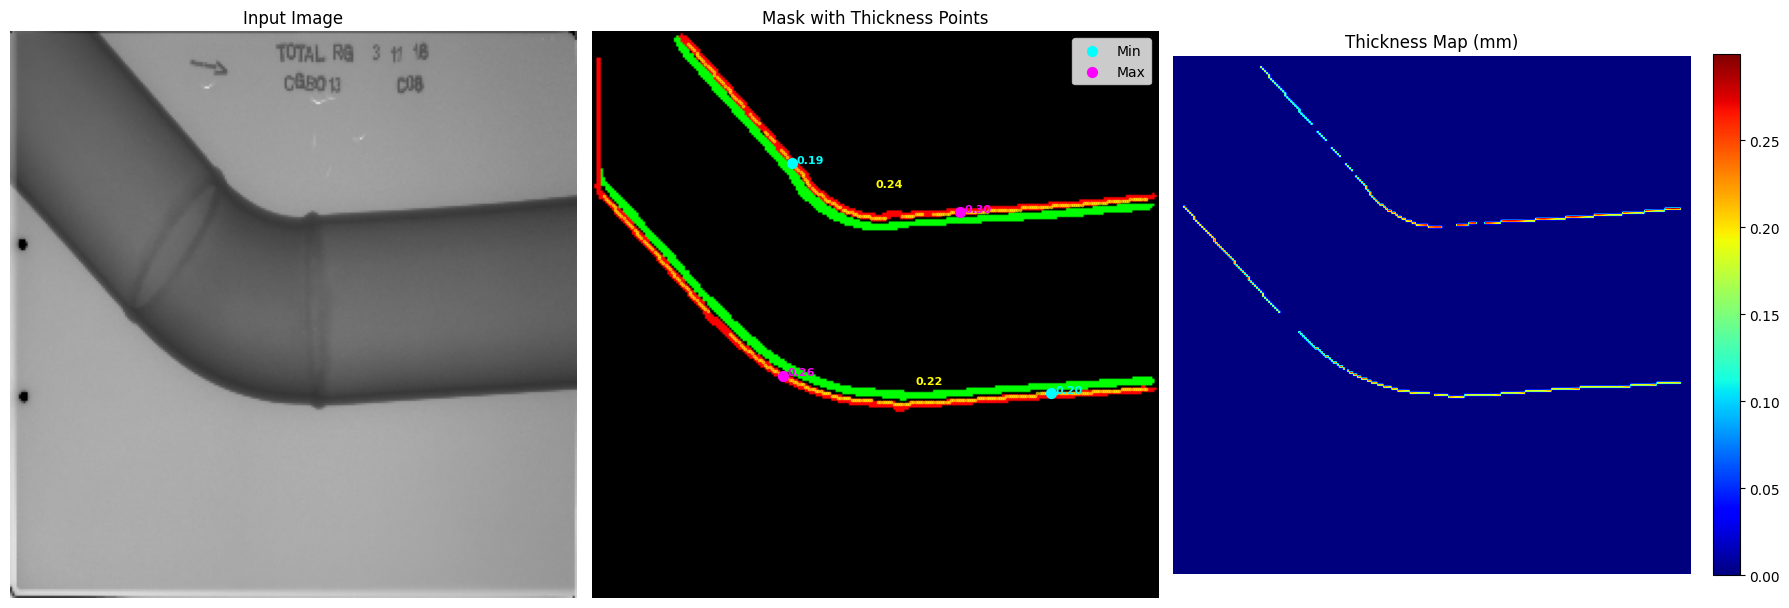

Segment 1: Min=0.20mm at (171,217), Max=0.28mm at (19,60), Mean=0.22mm
Saved 254 points to Test_1_segment_1_points.csv
Segment 2: Min=0.19mm at (62,132), Max=0.30mm at (89,191), Mean=0.24mm
Saved 161 points to Test_1_segment_2_points.csv


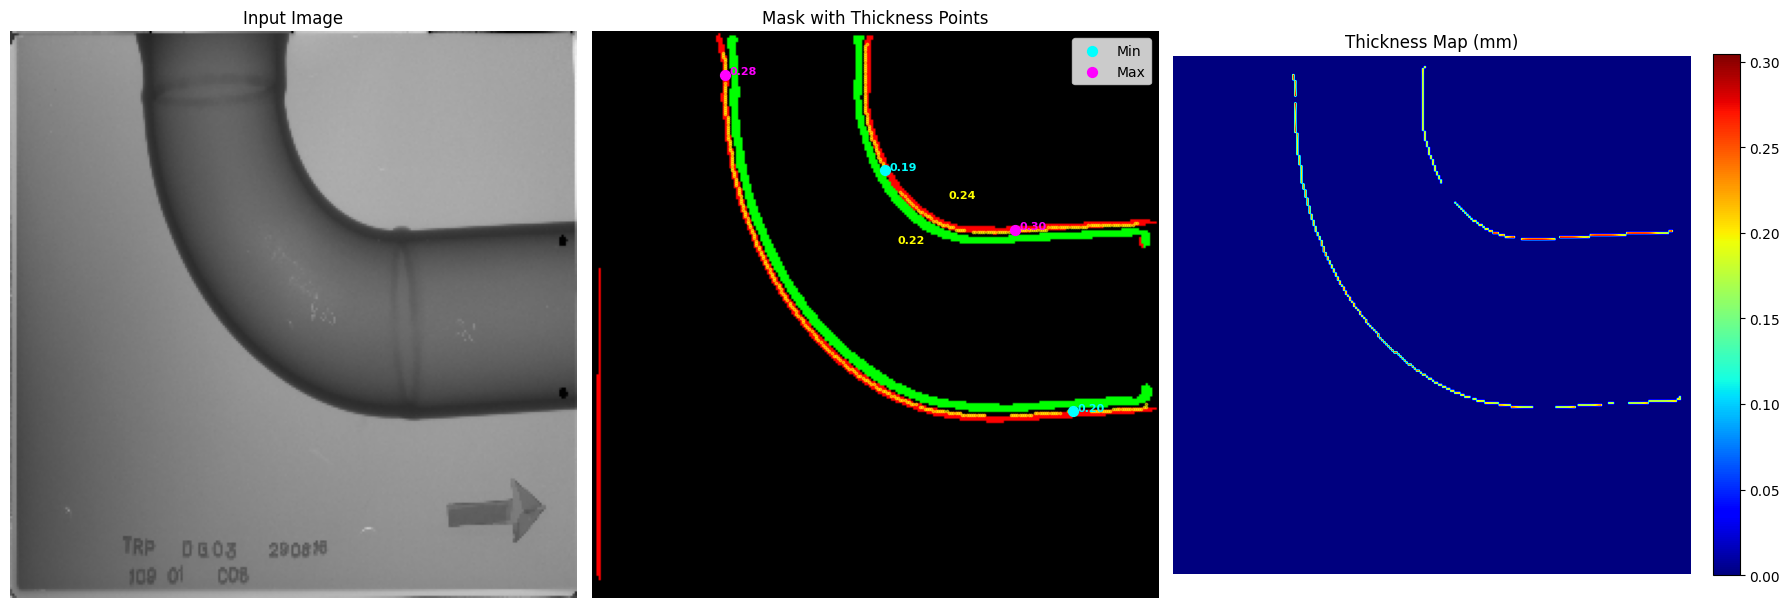

Segment 1: Min=0.18mm at (81,192), Max=0.25mm at (222,64), Mean=0.21mm
Saved 296 points to Test_2_segment_1_points.csv
Segment 2: Min=0.21mm at (140,67), Max=0.51mm at (17,130), Mean=0.28mm
Saved 205 points to Test_2_segment_2_points.csv


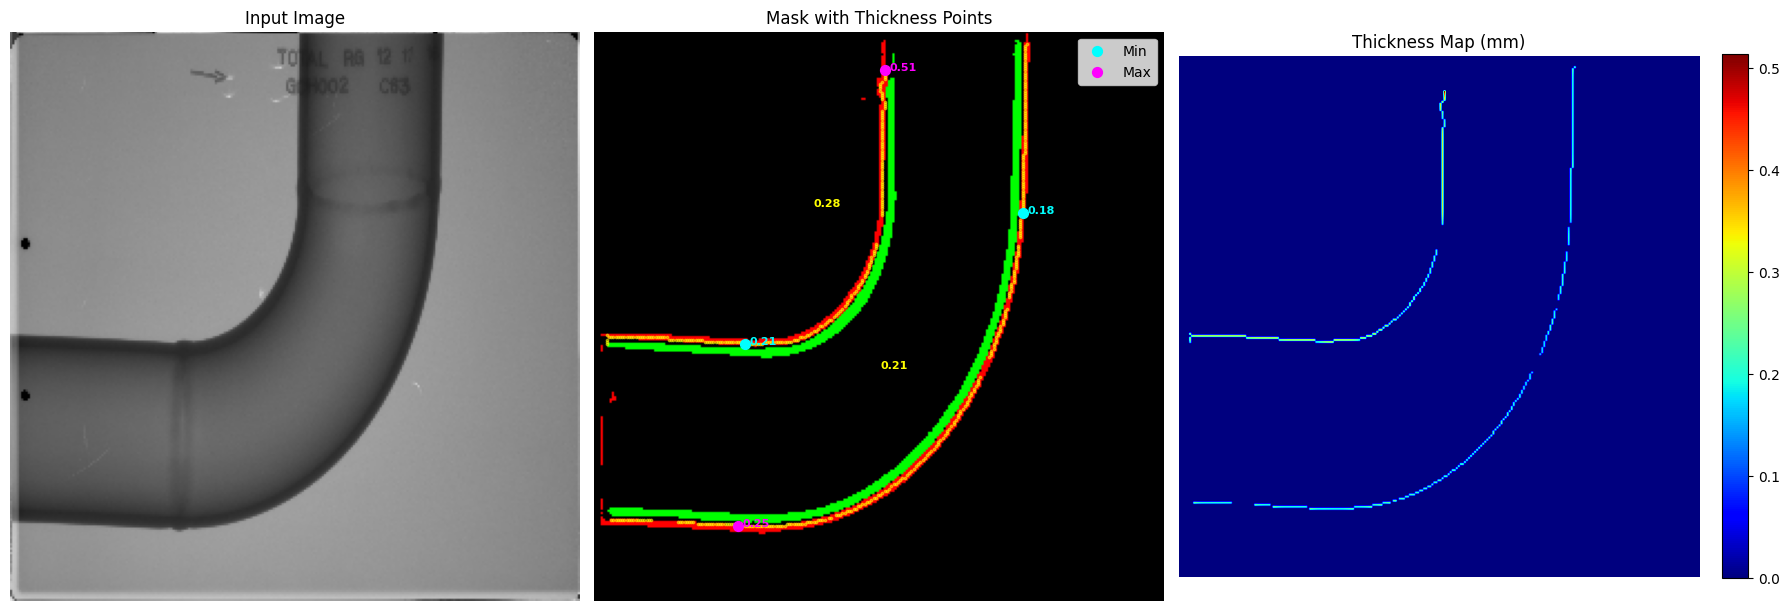

Segment 1: Min=0.20mm at (108,132), Max=2.48mm at (69,97), Mean=0.47mm
Saved 267 points to Test_3_segment_1_points.csv
Segment 2: Min=0.30mm at (137,13), Max=0.40mm at (136,19), Mean=0.33mm
Saved 246 points to Test_3_segment_2_points.csv
Segment 3: Min=0.20mm at (163,22), Max=0.22mm at (165,133), Mean=0.20mm
Saved 223 points to Test_3_segment_3_points.csv


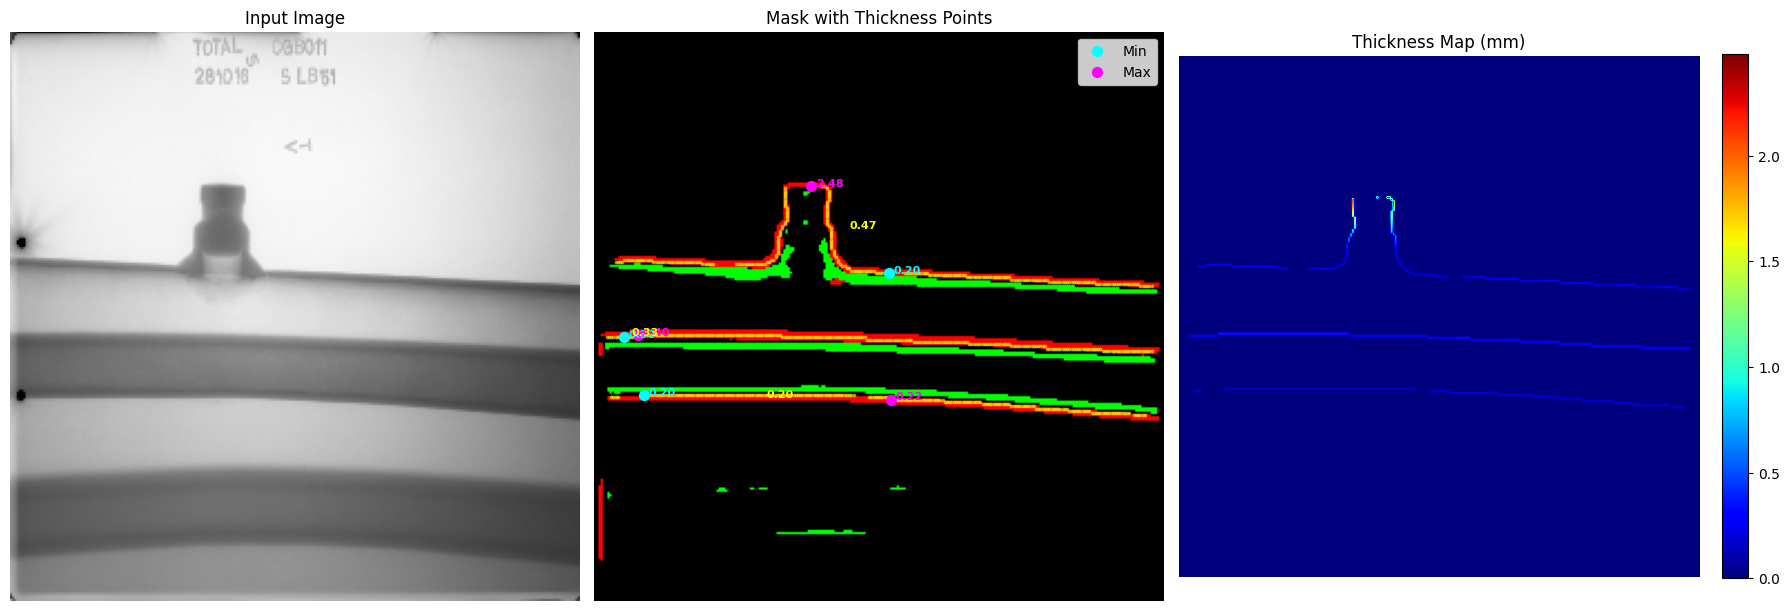

Segment 1: Min=0.30mm at (120,168), Max=1.21mm at (102,20), Mean=0.35mm
Saved 181 points to Test_4_segment_1_points.csv
Segment 3: Min=0.22mm at (232,65), Max=1.09mm at (169,12), Mean=0.40mm
Saved 134 points to Test_4_segment_3_points.csv
Segment 4: Min=0.20mm at (195,107), Max=0.43mm at (182,108), Mean=0.23mm
Saved 172 points to Test_4_segment_4_points.csv
Segment 5: Min=3.52mm at (210,208), Max=5.76mm at (218,244), Mean=4.42mm
Saved 37 points to Test_4_segment_5_points.csv


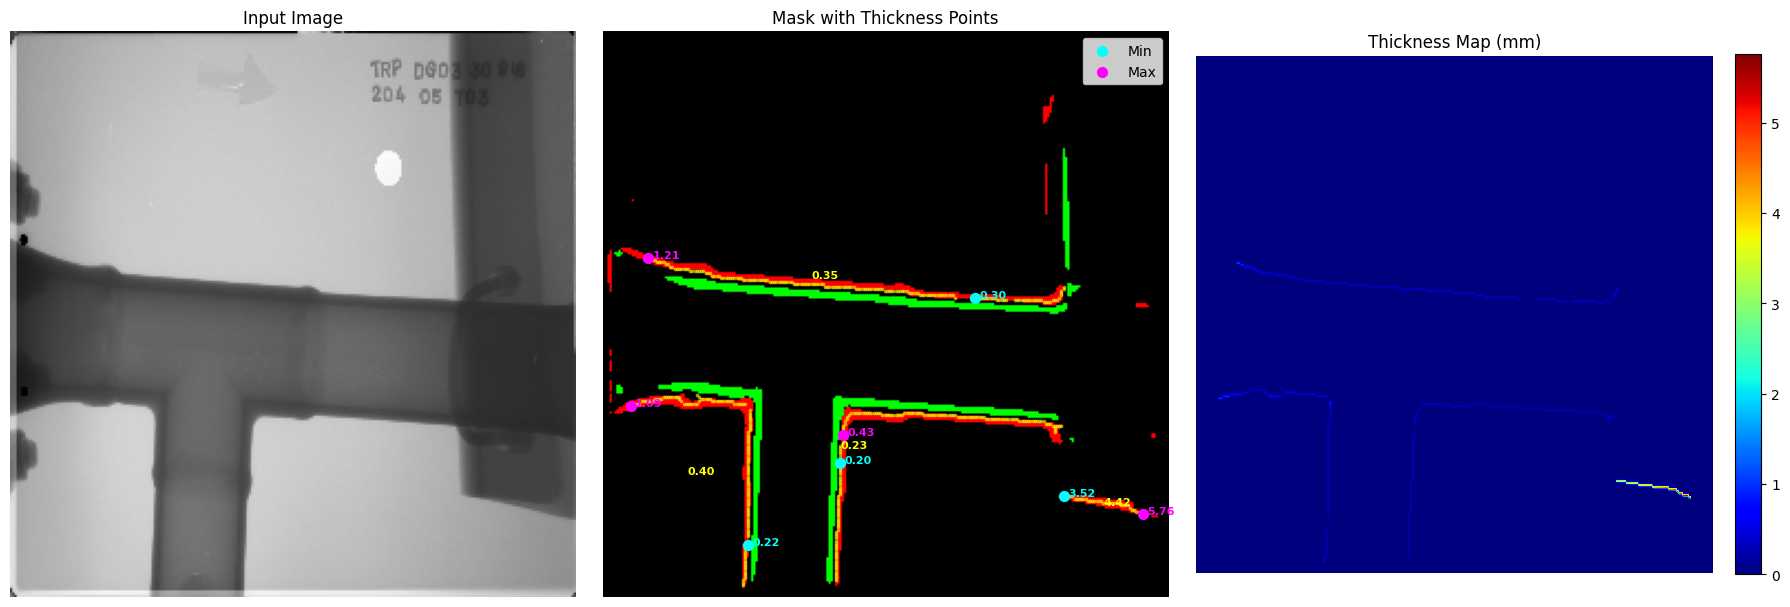

In [11]:
from scipy.ndimage import distance_transform_edt, gaussian_filter1d
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# ---------------------
# 1️⃣ Clean mask with gap bridging and noise removal
# ---------------------
def clean_pipe_mask(mask, min_component_area=200, bridge_kernel=5):
    mask = mask.copy().astype(np.uint8)
    if bridge_kernel > 1:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (bridge_kernel, bridge_kernel))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    cleaned = np.zeros_like(mask)
    for cls in [1, 2]:  # Outer=1, Inner=2
        binary = (mask == cls).astype(np.uint8)
        if np.count_nonzero(binary) == 0:
            continue
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
        keep_labels = [label_id for label_id in range(1, num_labels)
                       if stats[label_id, cv2.CC_STAT_AREA] >= min_component_area]
        if keep_labels:
            comp_mask = np.isin(labels, keep_labels).astype(np.uint8)
            cleaned[comp_mask == 1] = cls
    return cleaned

# ---------------------
# 2️⃣ Measure thickness per segment with percentile-based filtering
# ---------------------
def measure_pipe_wall_thickness(mask, min_wall_area=50, pixel_spacing=1.0,
                                border_margin=5, min_length=10, perc_low=5, perc_high=95):
    mask = clean_pipe_mask(mask, min_component_area=min_wall_area)
    outer_edge = (mask == 1).astype(np.uint8)
    inner_edge = (mask == 2).astype(np.uint8)
    if np.sum(outer_edge) == 0 or np.sum(inner_edge) == 0:
        raise ValueError("Missing outer or inner edge in mask")

    # Fill contours
    def fill_contour(edge_mask):
        filled = np.zeros_like(edge_mask, dtype=np.uint8)
        contours, _ = cv2.findContours(edge_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            cv2.drawContours(filled, contours, -1, 1, thickness=-1)
        return filled

    outer_filled = fill_contour(outer_edge)
    inner_filled = fill_contour(inner_edge)
    pipe_mask = cv2.bitwise_and(outer_filled, cv2.bitwise_not(inner_filled))

    # Remove small components
    num_labels, labels, stats_cc, _ = cv2.connectedComponentsWithStats(pipe_mask, connectivity=8)
    for i in range(1, num_labels):
        if stats_cc[i, cv2.CC_STAT_AREA] < min_wall_area:
            pipe_mask[labels == i] = 0
    if np.sum(pipe_mask) == 0:
        raise ValueError("No valid pipe wall after filtering")

    # Medial axis
    medial_axis = skeletonize(pipe_mask).astype(np.uint8)
    if np.sum(medial_axis) == 0:
        raise ValueError("No medial axis found")

    dist_to_outer = distance_transform_edt(1 - outer_edge)
    dist_to_inner = distance_transform_edt(1 - inner_edge)

    # Analyze segments
    segment_labels = label(pipe_mask)
    segments_stats = {}
    for region in regionprops(segment_labels):
        yy, xx = region.coords[:,0], region.coords[:,1]

        # Ignore border points
        valid = (yy >= border_margin) & (yy < mask.shape[0]-border_margin) & \
                (xx >= border_margin) & (xx < mask.shape[1]-border_margin)
        yy, xx = yy[valid], xx[valid]
        if len(yy) < min_length:
            continue

        # Medial axis points
        medial_mask = medial_axis[yy, xx] > 0
        yy_med, xx_med = yy[medial_mask], xx[medial_mask]
        if len(yy_med) < min_length:
            continue

        thickness = (dist_to_outer[yy_med, xx_med] + dist_to_inner[yy_med, xx_med]) * pixel_spacing
        if len(thickness) > 3:
            thickness = gaussian_filter1d(thickness, sigma=2)

        # Percentile-based outlier removal
        low, high = np.percentile(thickness, [perc_low, perc_high])
        valid_th = (thickness >= low) & (thickness <= high)
        thickness = thickness[valid_th]
        yy_med, xx_med = yy_med[valid_th], xx_med[valid_th]
        if len(thickness) == 0:
            continue

        min_idx, max_idx = np.argmin(thickness), np.argmax(thickness)
        segments_stats[region.label] = {
            'coords': (yy_med, xx_med),
            'thickness_mm': thickness,
            'min': (thickness[min_idx], (yy_med[min_idx], xx_med[min_idx])),
            'max': (thickness[max_idx], (yy_med[max_idx], xx_med[max_idx])),
            'mean': np.mean(thickness),
            'all_points': np.column_stack([yy_med, xx_med, thickness])
        }

    return segments_stats, pipe_mask

# ---------------------
# 3️⃣ Color mask
# ---------------------
def colorize_mask(mask):
    h, w = mask.shape
    colored = np.zeros((h, w, 3), dtype=np.uint8)
    colored[mask==1] = [255, 0, 0]   # Outer
    colored[mask==2] = [0, 255, 0]   # Inner
    return colored

# ---------------------
# 4️⃣ Visualization with all points
# ---------------------
def visualize_prediction_with_thickness(image, pred_mask, pixel_spacing=1.0, image_name=None):
    segments_stats, pipe_mask = measure_pipe_wall_thickness(pred_mask, pixel_spacing=pixel_spacing)

    color_mask = colorize_mask(pred_mask)
    thickness_map = np.zeros_like(pred_mask, dtype=np.float32)

    plt.figure(figsize=(18,6))

    # Input image
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Input Image")
    plt.axis('off')

    # Mask with all medial axis points
    plt.subplot(1,3,2)
    plt.imshow(color_mask)
    plt.title("Mask with Thickness Points")
    for seg_id, seg in segments_stats.items():
        yy, xx = seg['coords']
        thickness_map[yy, xx] = seg['thickness_mm']

        # Show all points
        plt.scatter(xx, yy, c='yellow', s=3, alpha=0.5)

        # Min, Max, Mean
        min_val, (my, mx) = seg['min']
        max_val, (MY, MX) = seg['max']
        mean_val = seg['mean']
        plt.scatter([mx], [my], c='cyan', s=50, label='Min' if seg_id==1 else "")
        plt.scatter([MX], [MY], c='magenta', s=50, label='Max' if seg_id==1 else "")
        plt.text(mx+2, my, f"{min_val:.2f}", color='cyan', fontsize=8, weight='bold')
        plt.text(MX+2, MY, f"{max_val:.2f}", color='magenta', fontsize=8, weight='bold')
        plt.text((mx+MX)//2, (my+MY)//2, f"{mean_val:.2f}", color='yellow', fontsize=8, weight='bold')

        print(f"Segment {seg_id}: Min={min_val:.2f}mm at ({my},{mx}), "
              f"Max={max_val:.2f}mm at ({MY},{MX}), Mean={mean_val:.2f}mm")

        # Save CSV of all points
        if image_name:
            csv_path = f"{image_name}_segment_{seg_id}_points.csv"
            np.savetxt(csv_path, seg['all_points'], delimiter=",",
                       header="y,x,thickness_mm", comments='', fmt="%.3f")
            print(f"Saved {len(seg['all_points'])} points to {csv_path}")

    plt.axis('off')
    plt.legend(loc='upper right')

    # Thickness map
    plt.subplot(1,3,3)
    im = plt.imshow(thickness_map, cmap='jet')
    plt.title("Thickness Map (mm)")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# ---------------------
# 5️⃣ Example usage
# ---------------------
preds = model.predict(X_test)
pred_labels = np.argmax(preds, axis=-1)

for i in range(min(5, len(X_test))):
    visualize_prediction_with_thickness(
        X_test[i], pred_labels[i], pixel_spacing=0.1, image_name=f"Test_{i}"
    )


Total images: 75
Train set: 53 samples
Validation set: 14 samples
Test set: 8 samples
Class weights: {0: 0.34096151239160677, 1: 20.0, 2: 20.0}
Epoch 1/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - dice_coef: 0.2262 - loss: 0.7146 - val_dice_coef: 0.2526 - val_loss: 0.6485 - learning_rate: 5.0000e-05
Epoch 2/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - dice_coef: 0.2501 - loss: 0.5067 - val_dice_coef: 0.2465 - val_loss: 0.5932 - learning_rate: 5.0000e-05
Epoch 3/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - dice_coef: 0.2640 - loss: 0.4731 - val_dice_coef: 0.2531 - val_loss: 0.5583 - learning_rate: 5.0000e-05
Epoch 4/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - dice_coef: 0.2796 - loss: 0.4430 - val_dice_coef: 0.2686 - val_loss: 0.5358 - learning_rate: 5.0000e-05
Epoch 5/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - dice_coef: 0.2870 - loss: 0.4259 - val_dice_coef: 0.2790 - val_loss: 0.5260 - learning_rate: 5.0000e-05
Epoch 6/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - dice_coef: 0.2986 - loss: 0.41

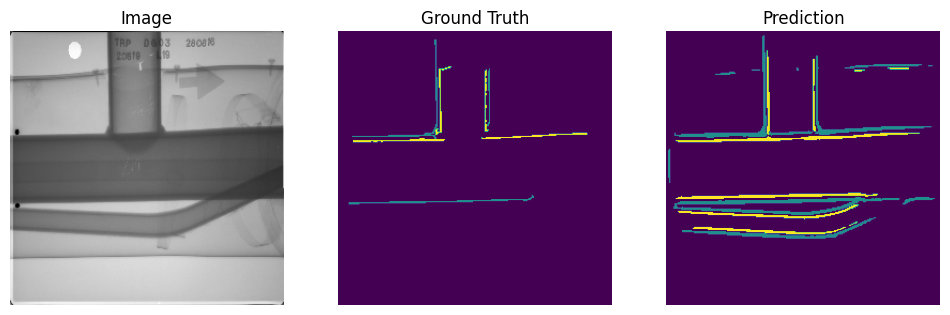

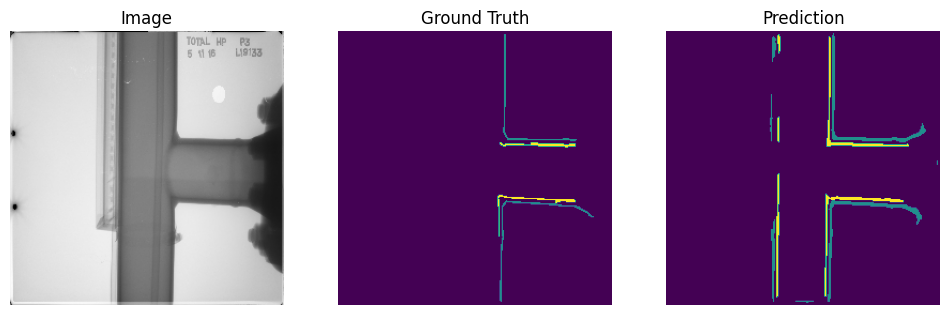

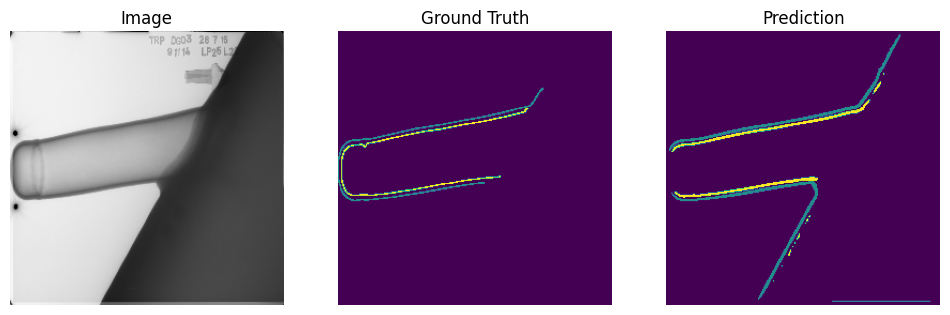

2025-08-21 14:08:12.870709: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
import os
import cv2
import numpy as np
import tensorflow as tf
import torch
from torch.nn import AdaptiveMaxPool2d
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D,
                                     concatenate, BatchNormalization, Activation, Dropout,
                                     Multiply, Add)
from tensorflow.keras.models import Model

# -----------------------------
# Configuration
# -----------------------------
IMG_HEIGHT, IMG_WIDTH = 256, 256
NUM_CLASSES = 3
BATCH_SIZE = 8
BUFFER_SIZE = 100
EPOCHS = 120

IMAGE_DIR = '/Users/salah/Desktop/intern/pipe_segmentation/images'
MASK_DIR = '/Users/salah/Desktop/intern/pipe_segmentation/generated_segmentation_masks'

# -----------------------------
# Data loading & preprocessing
# -----------------------------
def preprocess_mask(mask):
    # Map grayscale mask: 0/127/255 -> 0/1/2 (background/outer/inner)
    mask = np.where(mask == 127, 1, mask)
    mask = np.where(mask == 255, 2, mask)
    mask = np.where(mask < 1, 0, mask)
    return mask.astype(np.uint8)

def adaptive_maxpool_mask_resize(mask_np, output_size=(IMG_HEIGHT, IMG_WIDTH)):
    mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float()
    adaptive_pool = AdaptiveMaxPool2d(output_size)
    pooled_mask = adaptive_pool(mask_tensor)
    pooled_mask_np = pooled_mask.squeeze().byte().numpy()
    return pooled_mask_np

# Load images and masks
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith('.png')])

image_dict = {os.path.splitext(f)[0]: f for f in image_files}
mask_dict  = {os.path.splitext(f)[0].replace('_processed_annotated_mask', ''): f for f in mask_files}

X_list, Y_list = [], []

for base_name, img_file in image_dict.items():
    if base_name in mask_dict:
        img = cv2.imread(os.path.join(IMAGE_DIR, img_file))
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))

        mask = cv2.imread(os.path.join(MASK_DIR, mask_dict[base_name]), cv2.IMREAD_GRAYSCALE)
        mask = preprocess_mask(mask)
        mask = adaptive_maxpool_mask_resize(mask, (IMG_HEIGHT, IMG_WIDTH))

        X_list.append(img)
        Y_list.append(mask)

X = np.array(X_list, dtype=np.uint8)
Y = np.array(Y_list, dtype=np.uint8)

print(f"Total images: {len(X)}")

# One-hot encode masks
Y = tf.keras.utils.to_categorical(Y, num_classes=NUM_CLASSES)

# -----------------------------
# Train/val/test split
# -----------------------------
X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.2, random_state=42)

print(f"Train set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

# -----------------------------
# Class weights (pixel-level)
# -----------------------------
Y_train_labels = np.argmax(Y_train, axis=-1).astype(np.uint8)
all_pixels = Y_train_labels.flatten()
pixel_counts = Counter(all_pixels)
total_pixels = len(all_pixels)
class_weights = {cls: total_pixels / (NUM_CLASSES * count) for cls, count in pixel_counts.items()}
clipped_weights = {k: min(v, 20.0) for k, v in class_weights.items()}
print("Class weights:", clipped_weights)

weights_tensor = tf.constant([clipped_weights[i] for i in range(NUM_CLASSES)], dtype=tf.float32)

# -----------------------------
# Losses & metric
# -----------------------------
def weighted_focal_loss(alpha=weights_tensor, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=-1))
    return loss

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    return 1 - tf.reduce_mean((2. * intersection + smooth) / (denominator + smooth))

def combined_loss(y_true, y_pred):
    return 0.5 * weighted_focal_loss()(y_true, y_pred) + 0.5 * dice_loss(y_true, y_pred)

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    return tf.reduce_mean((2. * intersection + smooth) / (denominator + smooth))

# -----------------------------
# Building blocks
# -----------------------------
def conv_block(x, filters, dropout_rate=0.1):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    if dropout_rate and dropout_rate > 0:
        x = Dropout(dropout_rate)(x)
    return x

def attention_block(x, g, inter_channels):
    theta_x = Conv2D(inter_channels, (1, 1), padding='same')(x)
    phi_g   = Conv2D(inter_channels, (1, 1), padding='same')(g)
    add_xg  = Add()([theta_x, phi_g])
    act_xg  = Activation('relu')(add_xg)
    psi     = Conv2D(1, (1, 1), padding='same')(act_xg)
    psi     = Activation('sigmoid')(psi)
    out     = Multiply()([x, psi])
    return out

def attention_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    inputs = Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D()(c1)

    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D()(c2)

    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D()(c3)

    c4 = conv_block(p3, 512, dropout_rate=0.3)

    # Decoder + Attention
    u5  = UpSampling2D()(c4)
    a3  = attention_block(c3, u5, inter_channels=256)
    u5  = concatenate([u5, a3])
    c5  = conv_block(u5, 256)

    u6  = UpSampling2D()(c5)
    a2  = attention_block(c2, u6, inter_channels=128)
    u6  = concatenate([u6, a2])
    c6  = conv_block(u6, 128)

    u7  = UpSampling2D()(c6)
    a1  = attention_block(c1, u7, inter_channels=64)
    u7  = concatenate([u7, a1])
    c7  = conv_block(u7, 64)

    outputs = Conv2D(num_classes, 1, activation='softmax')(c7)
    return Model(inputs, outputs)

# -----------------------------
# Build & compile model
# -----------------------------
model = attention_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=combined_loss,
    metrics=[dice_coef]
)

# -----------------------------
# Callbacks
# -----------------------------
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)
]

# -----------------------------
# Data pipeline + augmentation
# -----------------------------
def augment(image, mask):
    image = tf.cast(image, tf.float32)
    mask  = tf.cast(mask, tf.float32)

    seed = tf.random.uniform([], maxval=10000, dtype=tf.int32)
    image = tf.image.stateless_random_flip_left_right(image, seed=[seed,0])
    mask  = tf.image.stateless_random_flip_left_right(mask,  seed=[seed,0])
    image = tf.image.stateless_random_flip_up_down(image,  seed=[seed,1])
    mask  = tf.image.stateless_random_flip_up_down(mask,    seed=[seed,1])

    image = tf.image.stateless_random_brightness(image, 0.2, seed=[seed,2])
    image = tf.image.stateless_random_contrast(image, 0.8,1.2, seed=[seed,3])
    image = tf.image.stateless_random_saturation(image, 0.8,1.2, seed=[seed,4])
    image = tf.image.stateless_random_hue(image, 0.05, seed=[seed,5])

    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask  = tf.image.rot90(mask,  k)

    return image, mask

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# -----------------------------
# Train model
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# -----------------------------
# Quick visualization
# -----------------------------
def visualize_prediction(model, dataset, num=3):
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds_labels = tf.argmax(preds, axis=-1)
        true_labels  = tf.argmax(masks, axis=-1)
        for i in range(min(num, images.shape[0])):
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.title("Image")
            plt.imshow(images[i].numpy().astype(np.uint8))
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.title("Ground Truth")
            plt.imshow(true_labels[i].numpy())
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.title("Prediction")
            plt.imshow(preds_labels[i].numpy())
            plt.axis('off')
            plt.show()

# Call visualization
visualize_prediction(model, val_ds, num=3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
Segment 1: Min=0.10mm at (102,33), Max=0.12mm at (75,8), Mean=0.10mm
Saved 238 points to Test_0_segment_1_points.csv


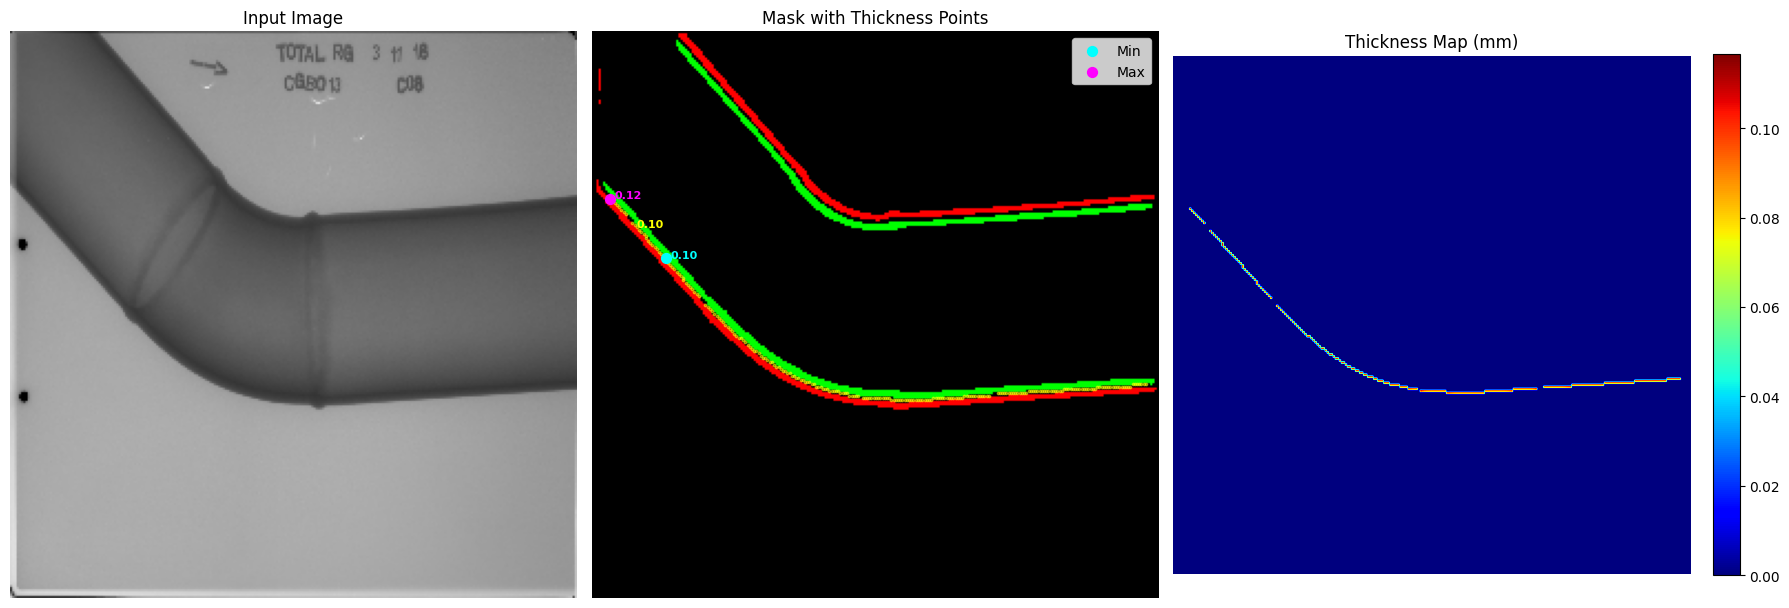

Segment 1: Min=0.10mm at (19,61), Max=0.18mm at (163,138), Mean=0.11mm
Saved 272 points to Test_1_segment_1_points.csv
Segment 2: Min=0.11mm at (94,176), Max=0.22mm at (70,132), Mean=0.18mm
Saved 163 points to Test_1_segment_2_points.csv


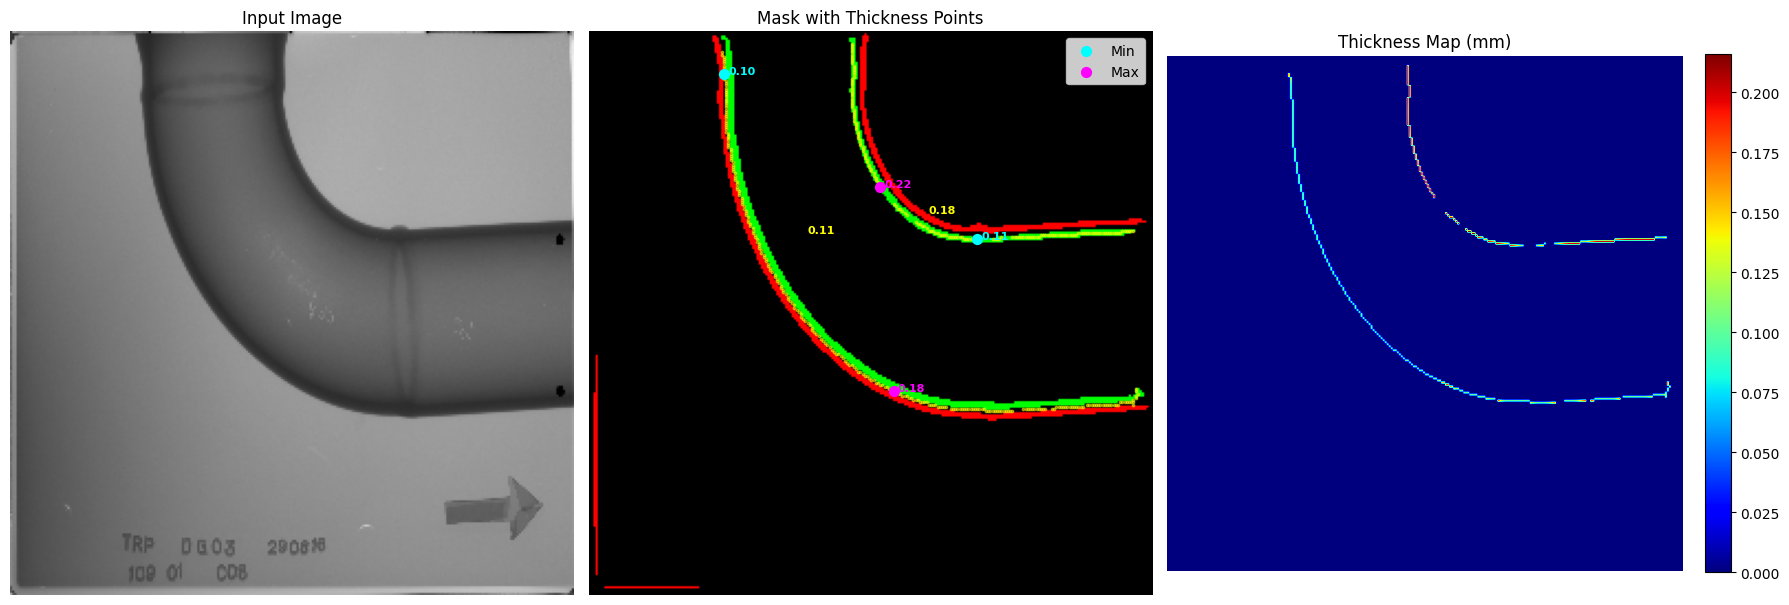

Segment 1: Min=0.10mm at (22,191), Max=0.21mm at (219,32), Mean=0.12mm
Saved 310 points to Test_2_segment_1_points.csv
Segment 2: Min=0.10mm at (141,13), Max=0.22mm at (85,132), Mean=0.19mm
Saved 202 points to Test_2_segment_2_points.csv


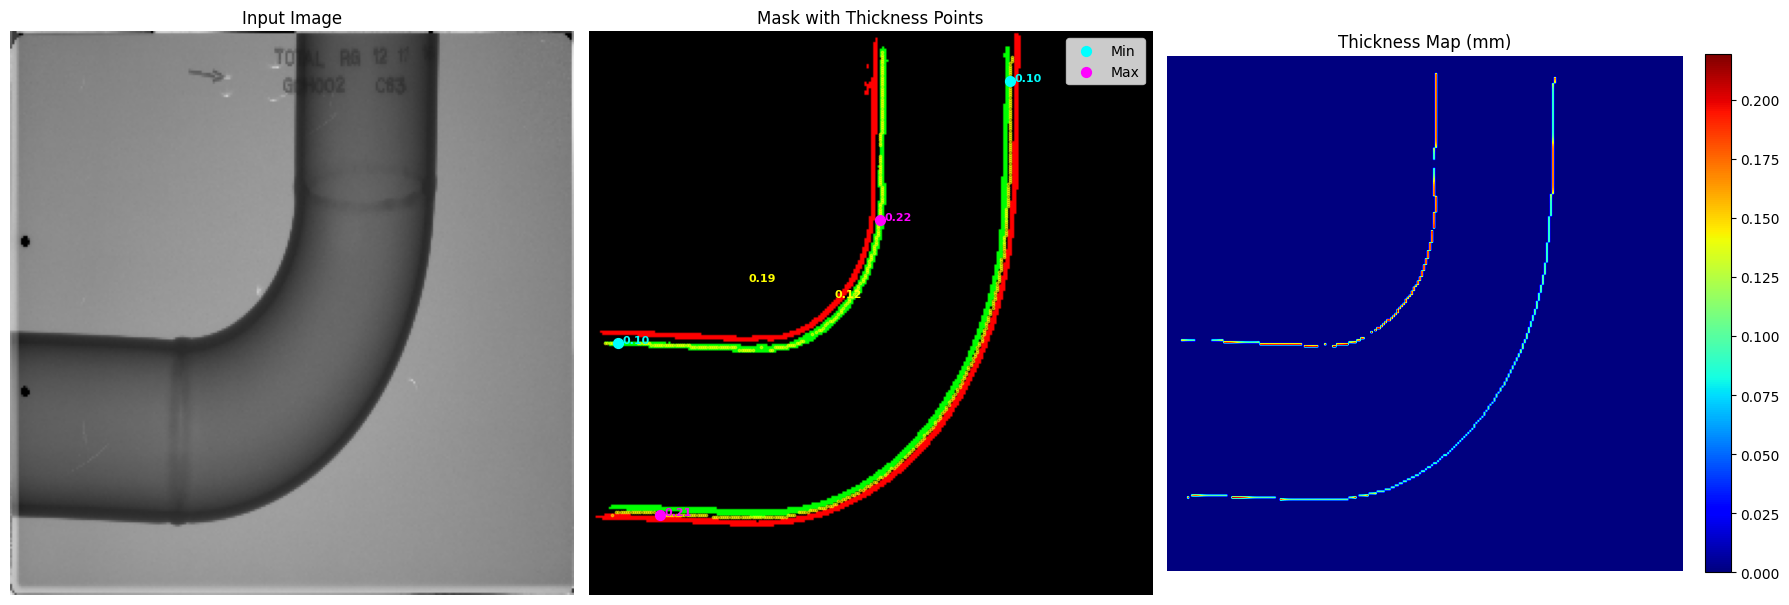

Segment 1: Min=0.10mm at (111,172), Max=2.88mm at (69,96), Mean=0.51mm
Saved 278 points to Test_3_segment_1_points.csv
Segment 2: Min=0.20mm at (138,77), Max=2.47mm at (142,229), Mean=0.64mm
Saved 223 points to Test_3_segment_2_points.csv


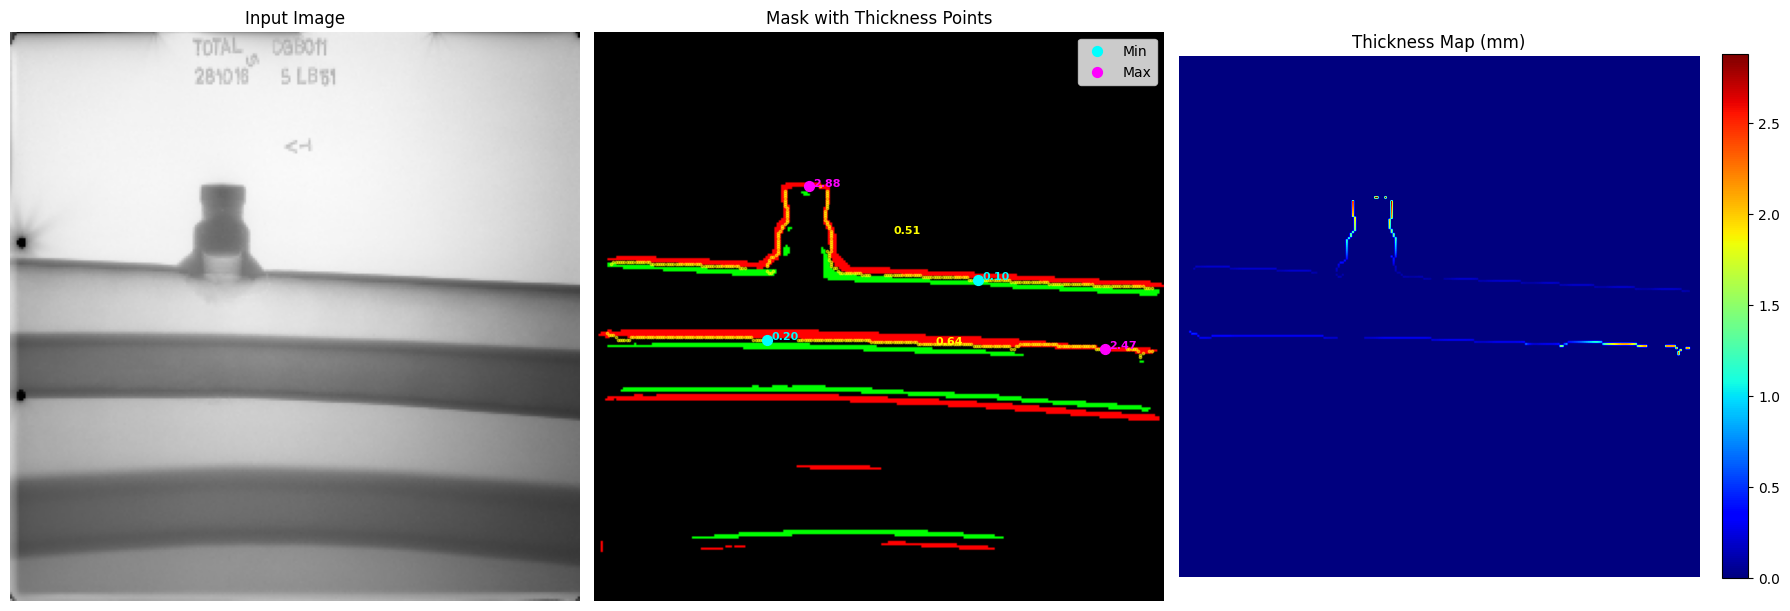

Segment 1: Min=0.37mm at (69,204), Max=0.91mm at (100,201), Mean=0.53mm
Saved 100 points to Test_4_segment_1_points.csv
Segment 2: Min=0.15mm at (123,188), Max=1.87mm at (103,23), Mean=0.37mm
Saved 199 points to Test_4_segment_2_points.csv


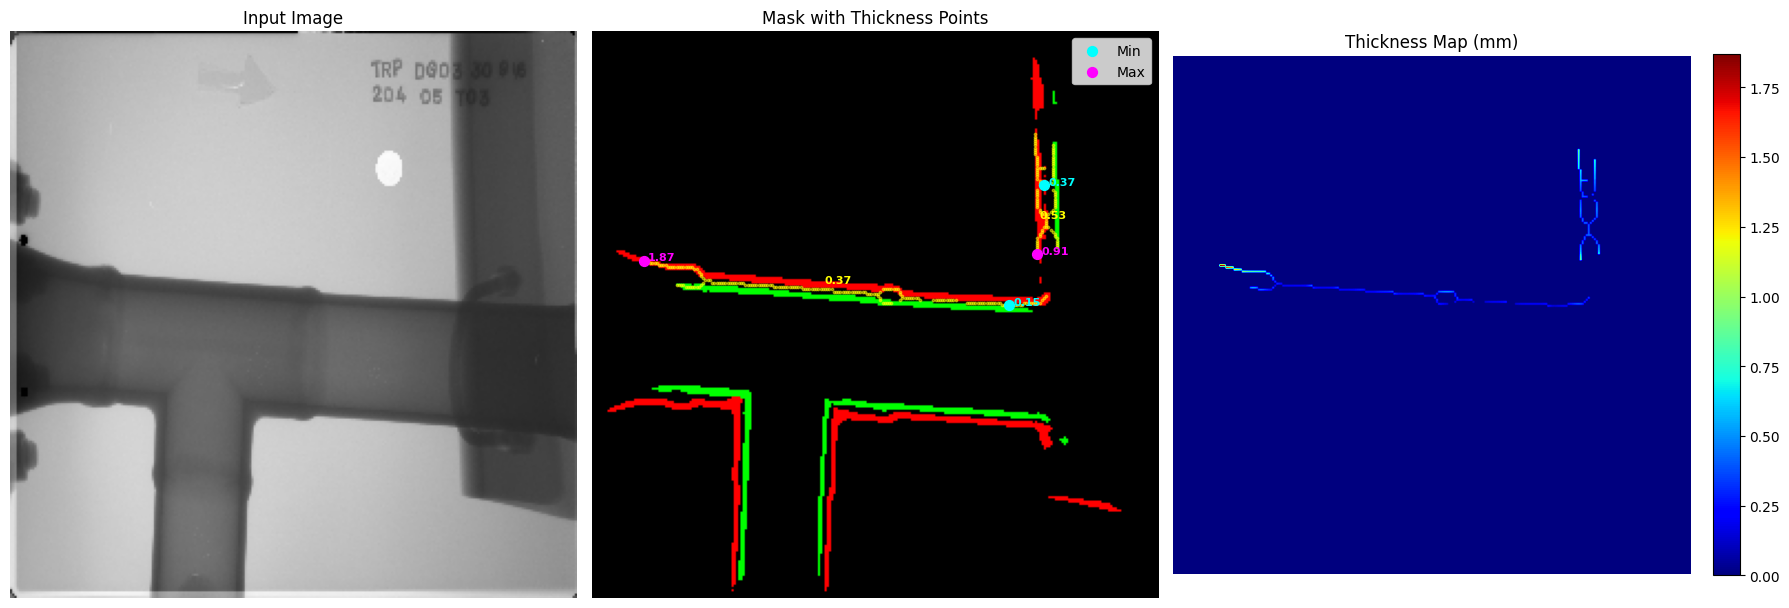

In [58]:
from scipy.ndimage import distance_transform_edt, gaussian_filter1d
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
import numpy as np
import cv2

# ---------------------
# 1️⃣ Clean mask with gap bridging and noise removal
# ---------------------
def clean_pipe_mask(mask, min_component_area=200, bridge_kernel=5):
    mask = mask.copy().astype(np.uint8)
    if bridge_kernel > 1:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (bridge_kernel, bridge_kernel))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    cleaned = np.zeros_like(mask)
    for cls in [1, 2]:  # Outer=1, Inner=2
        binary = (mask == cls).astype(np.uint8)
        if np.count_nonzero(binary) == 0:
            continue
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
        keep_labels = [label_id for label_id in range(1, num_labels)
                       if stats[label_id, cv2.CC_STAT_AREA] >= min_component_area]
        if keep_labels:
            comp_mask = np.isin(labels, keep_labels).astype(np.uint8)
            cleaned[comp_mask == 1] = cls
    return cleaned

# ---------------------
# 2️⃣ Measure thickness per segment, skip non-paired/noise
# ---------------------
def measure_pipe_wall_thickness(mask, min_wall_area=50, pixel_spacing=1.0,
                                border_margin=5, min_length=10, perc_low=5, perc_high=95):
    mask = clean_pipe_mask(mask, min_component_area=min_wall_area)
    outer_edge = (mask == 1).astype(np.uint8)
    inner_edge = (mask == 2).astype(np.uint8)

    if np.sum(outer_edge) == 0 or np.sum(inner_edge) == 0:
        return {}, mask  # Skip if no outer/inner edge

    # Fill contours
    def fill_contour(edge_mask):
        filled = np.zeros_like(edge_mask, dtype=np.uint8)
        contours, _ = cv2.findContours(edge_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            cv2.drawContours(filled, contours, -1, 1, thickness=-1)
        return filled

    outer_filled = fill_contour(outer_edge)
    inner_filled = fill_contour(inner_edge)
    pipe_mask = cv2.bitwise_and(outer_filled, cv2.bitwise_not(inner_filled))

    # Keep only paired components using bounding-box containment
    paired_mask = np.zeros_like(pipe_mask)
    outer_labels = label(outer_filled)
    inner_labels = label(inner_filled)

    for o_region in regionprops(outer_labels):
        o_minr, o_minc, o_maxr, o_maxc = o_region.bbox
        for i_region in regionprops(inner_labels):
            i_minr, i_minc, i_maxr, i_maxc = i_region.bbox
            # Check if inner bbox is fully inside outer bbox (with small margin)
            margin = 2
            if (i_minr >= o_minr - margin and i_maxr <= o_maxr + margin and
                i_minc >= o_minc - margin and i_maxc <= o_maxc + margin):
                paired_mask[(outer_labels==o_region.label) | (inner_labels==i_region.label)] = 1

    if np.sum(paired_mask) == 0:
        return {}, paired_mask  # skip if no paired segments

    # Medial axis
    medial_axis = skeletonize(paired_mask).astype(np.uint8)
    dist_to_outer = distance_transform_edt(1 - outer_edge)
    dist_to_inner = distance_transform_edt(1 - inner_edge)

    # Analyze paired segments
    segments_stats = {}
    segment_labels = label(paired_mask)
    for region in regionprops(segment_labels):
        yy, xx = region.coords[:,0], region.coords[:,1]

        valid = (yy >= border_margin) & (yy < mask.shape[0]-border_margin) & \
                (xx >= border_margin) & (xx < mask.shape[1]-border_margin)
        yy, xx = yy[valid], xx[valid]
        if len(yy) < min_length:
            continue

        medial_mask = medial_axis[yy, xx] > 0
        yy_med, xx_med = yy[medial_mask], xx[medial_mask]
        if len(yy_med) < min_length:
            continue

        thickness = (dist_to_outer[yy_med, xx_med] + dist_to_inner[yy_med, xx_med]) * pixel_spacing
        if len(thickness) > 3:
            thickness = gaussian_filter1d(thickness, sigma=2)

        low, high = np.percentile(thickness, [perc_low, perc_high])
        valid_th = (thickness >= low) & (thickness <= high)
        thickness = thickness[valid_th]
        yy_med, xx_med = yy_med[valid_th], xx_med[valid_th]
        if len(thickness) == 0:
            continue

        min_idx, max_idx = np.argmin(thickness), np.argmax(thickness)
        segments_stats[region.label] = {
            'coords': (yy_med, xx_med),
            'thickness_mm': thickness,
            'min': (thickness[min_idx], (yy_med[min_idx], xx_med[min_idx])),
            'max': (thickness[max_idx], (yy_med[max_idx], xx_med[max_idx])),
            'mean': np.mean(thickness),
            'all_points': np.column_stack([yy_med, xx_med, thickness])
        }

    return segments_stats, paired_mask

# ---------------------
# 3️⃣ Color mask
# ---------------------
def colorize_mask(mask):
    h, w = mask.shape
    colored = np.zeros((h, w, 3), dtype=np.uint8)
    colored[mask==1] = [255, 0, 0]   # Outer
    colored[mask==2] = [0, 255, 0]   # Inner
    return colored

# ---------------------
# 4️⃣ Visualize predictions with paired segments only
# ---------------------
def visualize_prediction_with_thickness(image, pred_mask, pixel_spacing=1.0, image_name=None):
    segments_stats, paired_mask = measure_pipe_wall_thickness(pred_mask, pixel_spacing=pixel_spacing)

    color_mask = colorize_mask(pred_mask)
    thickness_map = np.zeros_like(pred_mask, dtype=np.float32)

    plt.figure(figsize=(18,6))

    # Input image
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Input Image")
    plt.axis('off')

    # Mask + thickness points
    plt.subplot(1,3,2)
    plt.imshow(color_mask)
    plt.title("Mask with Thickness Points")
    if not segments_stats:
        plt.text(pred_mask.shape[1]//2, pred_mask.shape[0]//2,
                 "No paired segments", color='red', fontsize=14, ha='center')
        print("No paired segments to measure")
    for seg_id, seg in segments_stats.items():
        yy, xx = seg['coords']
        thickness_map[yy, xx] = seg['thickness_mm']
        plt.scatter(xx, yy, c='yellow', s=3, alpha=0.5)

        min_val, (my, mx) = seg['min']
        max_val, (MY, MX) = seg['max']
        mean_val = seg['mean']
        plt.scatter([mx], [my], c='cyan', s=50, label='Min' if seg_id==1 else "")
        plt.scatter([MX], [MY], c='magenta', s=50, label='Max' if seg_id==1 else "")
        plt.text(mx+2, my, f"{min_val:.2f}", color='cyan', fontsize=8, weight='bold')
        plt.text(MX+2, MY, f"{max_val:.2f}", color='magenta', fontsize=8, weight='bold')
        plt.text((mx+MX)//2, (my+MY)//2, f"{mean_val:.2f}", color='yellow', fontsize=8, weight='bold')

        print(f"Segment {seg_id}: Min={min_val:.2f}mm at ({my},{mx}), "
              f"Max={max_val:.2f}mm at ({MY},{MX}), Mean={mean_val:.2f}mm")

        if image_name:
            csv_path = f"{image_name}_segment_{seg_id}_points.csv"
            np.savetxt(csv_path, seg['all_points'], delimiter=",",
                       header="y,x,thickness_mm", comments='', fmt="%.3f")
            print(f"Saved {len(seg['all_points'])} points to {csv_path}")

    plt.axis('off')
    plt.legend(loc='upper right')

    # Thickness map
    plt.subplot(1,3,3)
    im = plt.imshow(thickness_map, cmap='jet')
    plt.title("Thickness Map (mm)")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# ---------------------
# 5️⃣ Run on test set
# ---------------------
preds = model.predict(X_test)
pred_labels = np.argmax(preds, axis=-1)

for i in range(min(5, len(X_test))):
    visualize_prediction_with_thickness(
        X_test[i], pred_labels[i], pixel_spacing=0.1, image_name=f"Test_{i}"
    )


In [59]:
pip install torch torchvision --upgrade

Note: you may need to restart the kernel to use updated packages.


Using device: cpu
Train set: 53
Val set:   14
Test set:  8
Approx class weights (semantic): {0: 0.33543881818359217, 1: 20.0, 2: 20.0}
Epoch 1: train loss = 2.1262
val loss = 1.2923
  ✅ Saved best model (val loss improved).
Epoch 2: train loss = 1.3972
val loss = 1.1879
  ✅ Saved best model (val loss improved).
Epoch 3: train loss = 1.3284
val loss = 1.1800
  ✅ Saved best model (val loss improved).
Epoch 4: train loss = 1.2875
val loss = 1.1726
  ✅ Saved best model (val loss improved).
Epoch 5: train loss = 1.2610
val loss = 1.1967
Epoch 6: train loss = 1.3008
val loss = 1.0592
  ✅ Saved best model (val loss improved).
Epoch 7: train loss = 1.2447
val loss = 1.1553
Epoch 8: train loss = 1.2134
val loss = 1.0344
  ✅ Saved best model (val loss improved).
Epoch 9: train loss = 1.1755
val loss = 1.0494
Epoch 10: train loss = 1.2878
val loss = 1.1235
Best val loss: 1.0344281707491194


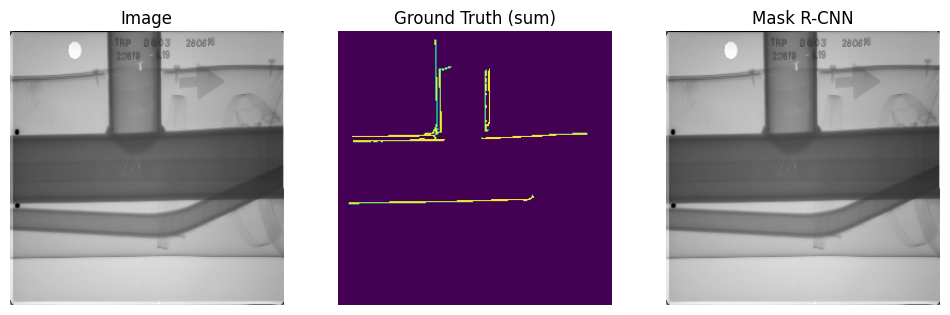

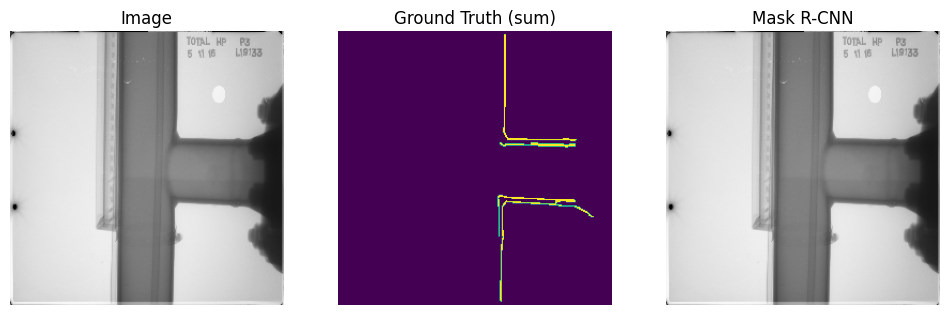

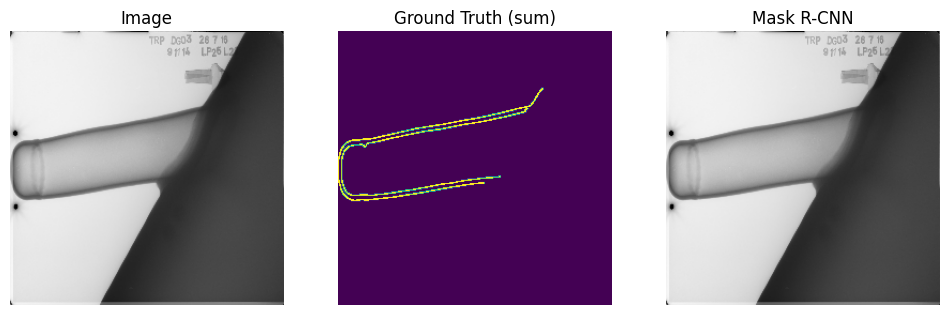

In [1]:
# ============================
# Mask R-CNN — full pipeline
# ============================
import os
import cv2
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

import torch
from torch.nn import AdaptiveMaxPool2d
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torchvision.transforms.functional as F

# -----------------------------
# Configuration (matches yours)
# -----------------------------
IMG_HEIGHT, IMG_WIDTH = 256, 256
NUM_CLASSES = 3            # background=0, outer=1, inner=2
BATCH_SIZE = 2            # smaller for CPU
EPOCHS = 10               # instance models converge faster than U-Net in practice

IMAGE_DIR = '/Users/salah/Desktop/intern/pipe_segmentation/images'
MASK_DIR  = '/Users/salah/Desktop/intern/pipe_segmentation/generated_segmentation_masks'

DEVICE = torch.device('cpu')   # MacBook Air CPU
print("Using device:", DEVICE)

# -----------------------------
# Preprocessing (same logic)
# -----------------------------
def preprocess_mask(mask):
    mask = np.where(mask == 127, 1, mask)
    mask = np.where(mask == 255, 2, mask)
    mask = np.where(mask < 1, 0, mask)
    return mask.astype(np.uint8)

def adaptive_maxpool_mask_resize(mask_np, output_size=(IMG_HEIGHT, IMG_WIDTH)):
    mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float()
    pooled = AdaptiveMaxPool2d(output_size)(mask_tensor)
    return pooled.squeeze().byte().numpy()

# ---------------------------------------
# Gather paired image/mask file lists
# ---------------------------------------
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith('.png')])
mask_files  = sorted([f for f in os.listdir(MASK_DIR)  if f.lower().endswith('.png')])

image_dict = {os.path.splitext(f)[0]: f for f in image_files}
# Your masks have suffix "_processed_annotated_mask"
mask_dict  = {os.path.splitext(f)[0].replace('_processed_annotated_mask', ''): f for f in mask_files}

X_paths, Y_paths = [], []
for base, img_name in image_dict.items():
    if base in mask_dict:
        X_paths.append(os.path.join(IMAGE_DIR, img_name))
        Y_paths.append(os.path.join(MASK_DIR,  mask_dict[base]))

if len(X_paths) == 0:
    raise FileNotFoundError("No paired images/masks found. Check IMAGE_DIR, MASK_DIR, and filename suffix mapping.")

# -----------------------------
# Train / Val / Test split
# -----------------------------
X_temp, X_test, Y_temp, Y_test = train_test_split(X_paths, Y_paths, test_size=0.1, random_state=42)
X_train, X_val,  Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.2, random_state=42)

print(f"Train set: {len(X_train)}")
print(f"Val set:   {len(X_val)}")
print(f"Test set:  {len(X_test)}")

# -----------------------------
# PyTorch Dataset
# -----------------------------
class PipeInstanceDataset(Dataset):
    """
    Builds instance targets for Mask R-CNN from semantic labelmaps (0/1/2).
    Splits disconnected components per class into separate instances.
    Filters tiny/degenerate instances to avoid invalid boxes.
    """
    def __init__(self, img_paths, mask_paths, min_area=25, min_side=2):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.min_area = min_area
        self.min_side = min_side  # ensures positive width/height boxes

    def __len__(self):
        return len(self.img_paths)

    def _instances_from_labelmap(self, lbl):
        H, W = lbl.shape
        masks_list, labels_list, boxes_list = [], [], []

        for cls_id in (1, 2):  # outer, inner
            bin_mask = (lbl == cls_id).astype(np.uint8)
            if bin_mask.sum() == 0:
                continue

            # Split into connected components
            num, comp = cv2.connectedComponents(bin_mask, connectivity=8)
            for cid in range(1, num):
                inst = (comp == cid).astype(np.uint8)
                area = int(inst.sum())
                if area < self.min_area:
                    continue

                ys, xs = np.where(inst)
                x1, x2 = int(xs.min()), int(xs.max())
                y1, y2 = int(ys.min()), int(ys.max())

                # Ensure positive width/height (avoid AssertionError)
                if (x2 - x1 + 1) < self.min_side or (y2 - y1 + 1) < self.min_side:
                    continue

                masks_list.append(inst)
                labels_list.append(cls_id)
                boxes_list.append([x1, y1, x2, y2])

        if len(masks_list) == 0:
            # No instances: return valid empty tensors
            return (
                torch.zeros((0, 4), dtype=torch.float32),
                torch.zeros((0,), dtype=torch.int64),
                torch.zeros((0, H, W), dtype=torch.uint8)
            )

        masks = torch.from_numpy(np.stack(masks_list, axis=0)).to(torch.uint8)  # [N,H,W]
        boxes = torch.as_tensor(boxes_list, dtype=torch.float32)               # [N,4]
        labels = torch.as_tensor(labels_list, dtype=torch.int64)               # [N]
        return boxes, labels, masks

    def __getitem__(self, idx):
        # Image
        img = cv2.imread(self.img_paths[idx])
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Mask -> semantic (0/1/2) -> resize with adaptive max pool
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = preprocess_mask(mask)
        mask = adaptive_maxpool_mask_resize(mask, (IMG_HEIGHT, IMG_WIDTH))

        # Build instances
        boxes, labels, masks = self._instances_from_labelmap(mask)

        # Pack target
        target = {
            "boxes":  boxes,          # [N,4]  (x1,y1,x2,y2)
            "labels": labels,         # [N]
            "masks":  masks,          # [N,H,W] uint8
            "image_id": torch.tensor([idx]),
            "iscrowd": torch.zeros((labels.shape[0],), dtype=torch.int64),
        }
        # area is optional but useful
        if masks.numel() > 0:
            target["area"] = masks.flatten(1).sum(dim=1).to(torch.float32)
        else:
            target["area"] = torch.zeros((0,), dtype=torch.float32)

        # To tensor in [0,1], CxHxW
        img = F.to_tensor(img)
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))  # list of images, list of targets

train_ds = PipeInstanceDataset(X_train, Y_train)
val_ds   = PipeInstanceDataset(X_val,   Y_val)
test_ds  = PipeInstanceDataset(X_test,  Y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)

# -----------------------------
# Class weights (optional info)
# -----------------------------
# (Semantic pixel weights not used directly by Mask R-CNN, but we show how you'd compute them)
def estimate_class_weights(mask_paths):
    counts = Counter()
    total = 0
    for p in mask_paths:
        m = preprocess_mask(cv2.imread(p, cv2.IMREAD_GRAYSCALE))
        total += m.size
        for c in (0,1,2):
            counts[c] += int((m == c).sum())
    weights = {}
    for c in (0,1,2):
        if counts[c] == 0:
            weights[c] = 1.0
        else:
            weights[c] = total / (len(counts) * counts[c])
    # clip for stability
    for k in weights:
        weights[k] = float(min(weights[k], 20.0))
    return weights

print("Approx class weights (semantic):", estimate_class_weights(Y_train))

# -----------------------------
# Model: Mask R-CNN
# -----------------------------
model = maskrcnn_resnet50_fpn(weights="DEFAULT")  # start from COCO weights (helps on CPU)
# Replace heads for our number of classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, NUM_CLASSES)
model.to(DEVICE)

# -----------------------------
# Optimizer, LR schedule, EarlyStopping
# -----------------------------
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=5e-4, weight_decay=1e-4)

# PyTorch ReduceLROnPlateau on CPU (no 'verbose' arg in some versions)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience
        self.best = float('inf')
        self.count = 0
    def step(self, val_loss):
        if val_loss < self.best - 1e-6:
            self.best = val_loss
            self.count = 0
            return True  # improved
        else:
            self.count += 1
            return self.count < self.patience

early = EarlyStopping(patience=10)

# -----------------------------
# Train / Val loops
# -----------------------------
def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    running = 0.0
    for images, targets in loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)  # built-in cls/box/mask + rpn losses
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item()
    avg = running / max(1, len(loader))
    print(f"Epoch {epoch}: train loss = {avg:.4f}")
    return avg

@torch.no_grad()
def validate(model, loader):
    model.train()  # ⚠️ important: force training mode to compute loss dict
    total = 0.0
    for images, targets in loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        
        # compute losses (dict)
        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())
        total += loss.item()
    
    avg = total / max(1, len(loader))
    print(f"val loss = {avg:.4f}")
    return avg

best_val = float('inf')
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, epoch)
    val_loss   = validate(model, val_loader)

    # scheduler & early stopping
    lr_scheduler.step(val_loss)
    improved = early.step(val_loss)
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        torch.save(model.state_dict(), "maskrcnn_pipe_best.pth")
        print("  ✅ Saved best model (val loss improved).")
    if not improved:
        print("Early stopping.")
        break

print("Best val loss:", best_val)

# -----------------------------
# Visualization on val samples
# -----------------------------
@torch.no_grad()
def visualize_predictions(model, dataset, num_images=3, score_thresh=0.5):
    model.eval()
    shown = 0
    for i in range(len(dataset)):
        if shown >= num_images:
            break
        img, target = dataset[i]
        out = model([img.to(DEVICE)])[0]
        img_np = (img.permute(1,2,0).numpy() * 255).astype(np.uint8).copy()

        # Prepare overlay
        overlay = img_np.copy()
        if 'scores' in out:
            keep = out['scores'].cpu().numpy() >= score_thresh
        else:
            keep = np.array([True] * len(out['boxes']))
        boxes = out['boxes'][keep].cpu().numpy().astype(int)
        labels = out['labels'][keep].cpu().numpy()
        masks  = out['masks'][keep].cpu().numpy() if 'masks' in out else np.zeros((0,1,IMG_HEIGHT,IMG_WIDTH))
        masks  = (masks > 0.5).astype(np.uint8)

        color_map = {1: (0, 0, 255), 2: (0, 255, 0)}  # BGR: outer=red, inner=green
        for m, lab, box in zip(masks, labels, boxes):
            m = m[0]
            color = color_map.get(int(lab), (255, 255, 255))
            colored = np.zeros_like(overlay)
            colored[m.astype(bool)] = color
            overlay = cv2.addWeighted(overlay, 1.0, colored, 0.4, 0)
            x1, y1, x2, y2 = box.tolist()
            cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)
            name = "outer" if lab == 1 else ("inner" if lab == 2 else "bg")
            cv2.putText(overlay, name, (x1, max(12, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)

        # Show
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.imshow(img_np); plt.title("Image"); plt.axis('off')
        gt = target["masks"].sum(0).numpy() if target["masks"].numel() > 0 else np.zeros((IMG_HEIGHT, IMG_WIDTH), dtype=np.uint8)
        plt.subplot(1,3,2); plt.imshow(gt); plt.title("Ground Truth (sum)"); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title("Mask R-CNN"); plt.axis('off')
        plt.show()
        shown += 1

# Load best and visualize
model.load_state_dict(torch.load("maskrcnn_pipe_best.pth", map_location=DEVICE))
visualize_predictions(model, val_ds, num_images=3, score_thresh=0.5)


Total images: 75
Train set: 53 samples
Validation set: 14 samples
Test set: 8 samples
Class weights: {0: 0.34096151239160677, 1: 20.0, 2: 20.0}
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - dice_coef: 0.1766 - loss: 0.7512 - val_dice_coef: 0.1628 - val_loss: 0.6127 - learning_rate: 5.0000e-05
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step - dice_coef: 0.1903 - loss: 0.6534 - val_dice_coef: 0.1747 - val_loss: 0.5986 - learning_rate: 5.0000e-05
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - dice_coef: 0.2014 - loss: 0.6066 - val_dice_coef: 0.1799 - val_loss: 0.5925 - learning_rate: 5.0000e-05
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - dice_coef: 0.2082 - loss: 0.5772 - val_dice_coef: 0.1834 - val_loss: 0.5887 - learning_rate: 5.0000e-05
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - dice_coef: 0.2195 - loss: 0.5521 - val_dice_coef: 0.1867 - val_loss: 0.5860 - learning_rate: 5.0000e-05
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - dice_coef: 0.2246 - loss: 0.5291 - v

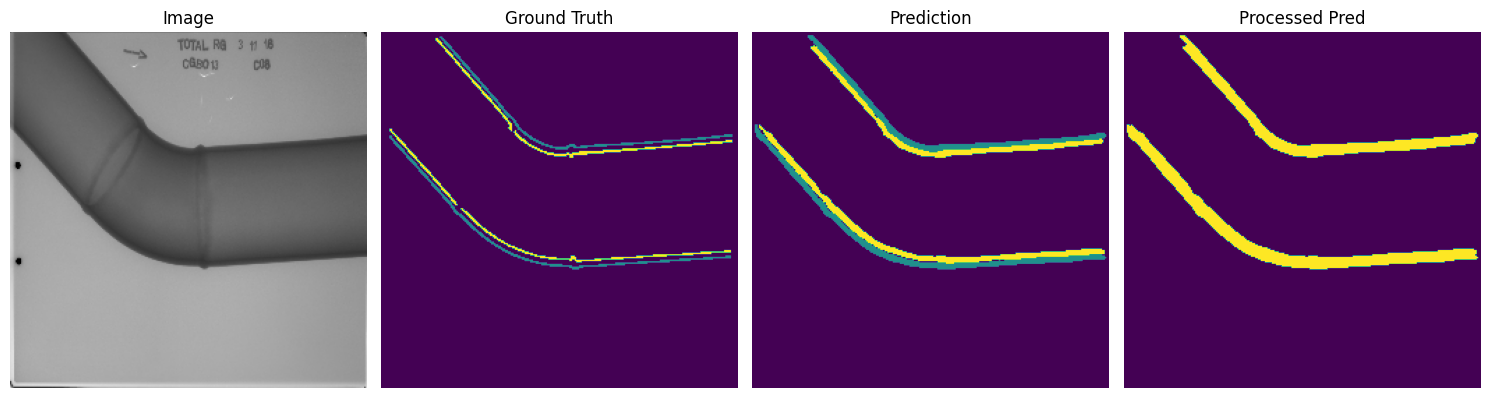

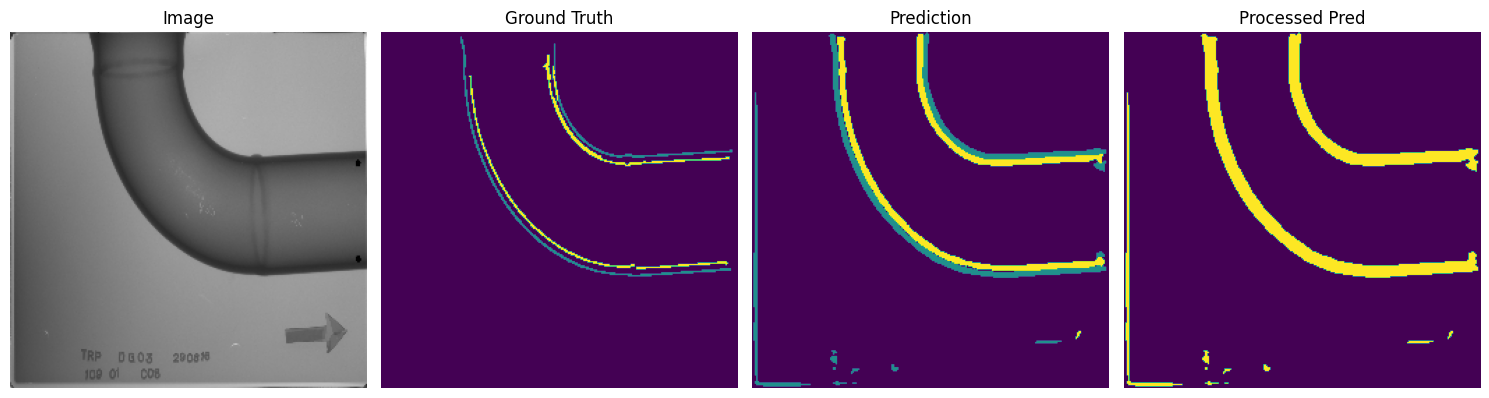

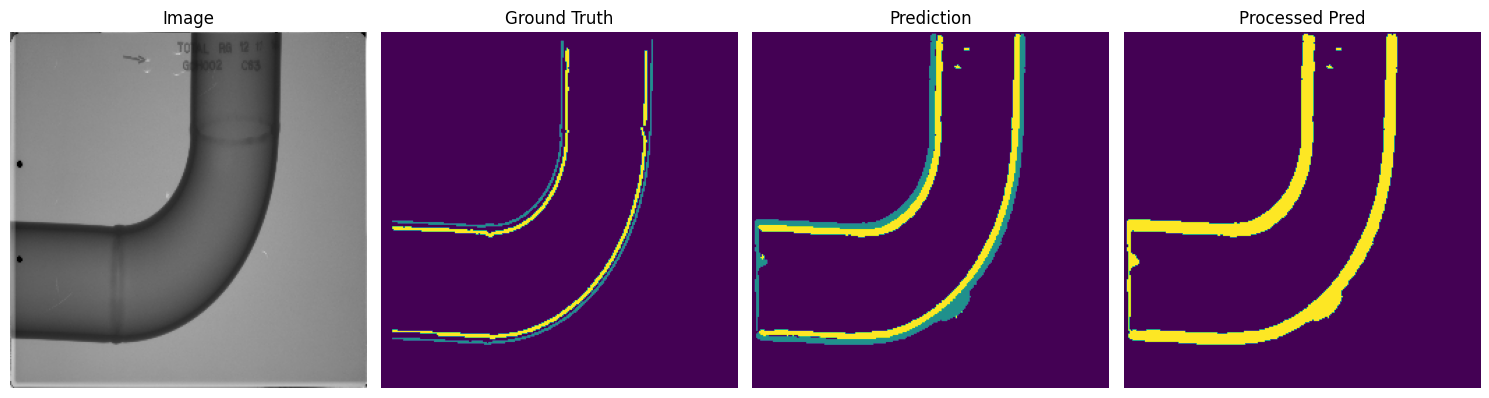

2025-08-25 11:33:08.701224: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
import os
import cv2
import numpy as np
import tensorflow as tf
import torch
from torch.nn import AdaptiveMaxPool2d
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D,
                                     concatenate, BatchNormalization, Activation, Dropout,
                                     Add, Subtract)
from tensorflow.keras.models import Model
import scipy.ndimage as ndi

# -----------------------------
# Configuration
# -----------------------------
IMG_HEIGHT, IMG_WIDTH = 256, 256
NUM_CLASSES = 3
BATCH_SIZE = 8
BUFFER_SIZE = 100
EPOCHS = 50

IMAGE_DIR = '/Users/salah/Desktop/intern/pipe_segmentation/images'
MASK_DIR = '/Users/salah/Desktop/intern/pipe_segmentation/generated_segmentation_masks'

# -----------------------------
# Data loading & preprocessing
# -----------------------------
def preprocess_mask(mask):
    mask = np.where(mask == 127, 1, mask)
    mask = np.where(mask == 255, 2, mask)
    mask = np.where(mask < 1, 0, mask)
    return mask.astype(np.uint8)

def adaptive_maxpool_mask_resize(mask_np, output_size=(IMG_HEIGHT, IMG_WIDTH)):
    mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float()
    adaptive_pool = AdaptiveMaxPool2d(output_size)
    pooled_mask = adaptive_pool(mask_tensor)
    pooled_mask_np = pooled_mask.squeeze().byte().numpy()
    return pooled_mask_np

# Load images and masks
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith('.png')])

image_dict = {os.path.splitext(f)[0]: f for f in image_files}
mask_dict = {os.path.splitext(f)[0].replace('_processed_annotated_mask', ''): f for f in mask_files}

X, Y = [], []

for base_name, img_file in image_dict.items():
    if base_name in mask_dict:
        img = cv2.imread(os.path.join(IMAGE_DIR, img_file))
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        mask = cv2.imread(os.path.join(MASK_DIR, mask_dict[base_name]), cv2.IMREAD_GRAYSCALE)
        mask = preprocess_mask(mask)
        mask = adaptive_maxpool_mask_resize(mask, (IMG_HEIGHT, IMG_WIDTH))
        X.append(img)
        Y.append(mask)

X = np.array(X, dtype=np.uint8)
Y = np.array(Y, dtype=np.uint8)

print(f"Total images: {len(X)}")

# One-hot encode masks
Y = tf.keras.utils.to_categorical(Y, num_classes=NUM_CLASSES)

# Train/val/test split
X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.2, random_state=42)

print(f"Train set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

# Class weights calculation
Y_train_labels = np.argmax(Y_train, axis=-1).astype(np.uint8)
all_pixels = Y_train_labels.flatten()
pixel_counts = Counter(all_pixels)
total_pixels = len(all_pixels)
class_weights = {cls: total_pixels / (NUM_CLASSES * count) for cls, count in pixel_counts.items()}
clipped_weights = {k: min(v, 20.0) for k, v in class_weights.items()}
print("Class weights:", clipped_weights)
weights_tensor = tf.constant([clipped_weights[i] for i in range(NUM_CLASSES)], dtype=tf.float32)

# -----------------------------
# Losses & Metrics
# -----------------------------
def weighted_focal_loss(alpha=weights_tensor, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=-1))
    return loss

def tversky_loss(y_true, y_pred, smooth=1e-6, alpha=0.7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])
    
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    fn = tf.reduce_sum(y_true_f * (1 - y_pred_f), axis=0)
    fp = tf.reduce_sum((1 - y_true_f) * y_pred_f, axis=0)
    
    tversky = (intersection + smooth) / (intersection + alpha * fn + (1 - alpha) * fp + smooth)
    return 1 - tf.reduce_mean(tversky)

def boundary_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Convert one-hot to labels for edge detection
    y_true_labels = tf.argmax(y_true, axis=-1)
    y_pred_labels = tf.argmax(y_pred, axis=-1)
    
    # Calculate boundaries
    true_boundary = tf.cast(tf.image.sobel_edges(tf.expand_dims(y_true_labels, -1)), tf.float32)
    pred_boundary = tf.cast(tf.image.sobel_edges(tf.expand_dims(y_pred_labels, -1)), tf.float32)
    
    true_boundary_norm = tf.norm(true_boundary, ord='euclidean', axis=-1)
    pred_boundary_norm = tf.norm(pred_boundary, ord='euclidean', axis=-1)

    # Simple boundary difference
    boundary_diff = tf.abs(true_boundary_norm - pred_boundary_norm)
    return tf.reduce_mean(boundary_diff)

def combined_loss(y_true, y_pred):
    tversky = tversky_loss(y_true, y_pred, alpha=0.7)
    focal = weighted_focal_loss()(y_true, y_pred)
    # The boundary loss is calculated on the argmax, so it should be used carefully,
    # or as a separate metric. For a combined loss, a better implementation
    # would be to use a continuous boundary loss.
    # For simplicity, we'll combine Tversky and Focal here.
    return 0.5 * focal + 0.5 * tversky

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    return tf.reduce_mean((2. * intersection + smooth) / (denominator + smooth))

# -----------------------------
# U-Net++ Architecture
# -----------------------------
def conv_block(x, filters, dropout_rate=0.1):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)
    return x

def unet_plus_plus(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    filters = [32, 64, 128, 256, 512]
    inputs = Input(input_shape)

    # Downsampling layers (X^0_0, X^1_0, X^2_0, ...)
    X_00 = conv_block(inputs, filters[0])
    p1 = MaxPooling2D()(X_00)
    X_10 = conv_block(p1, filters[1])
    p2 = MaxPooling2D()(X_10)
    X_20 = conv_block(p2, filters[2])
    p3 = MaxPooling2D()(X_20)
    X_30 = conv_block(p3, filters[3])
    p4 = MaxPooling2D()(X_30)
    X_40 = conv_block(p4, filters[4])

    # Intermediate layers (X^0_1, X^1_1, etc.)
    X_01 = conv_block(concatenate([UpSampling2D()(X_10), X_00]), filters[0])
    X_11 = conv_block(concatenate([UpSampling2D()(X_20), X_10]), filters[1])
    X_21 = conv_block(concatenate([UpSampling2D()(X_30), X_20]), filters[2])
    X_31 = conv_block(concatenate([UpSampling2D()(X_40), X_30]), filters[3])

    X_02 = conv_block(concatenate([UpSampling2D()(X_11), X_01]), filters[0])
    X_12 = conv_block(concatenate([UpSampling2D()(X_21), X_11]), filters[1])
    X_22 = conv_block(concatenate([UpSampling2D()(X_31), X_21]), filters[2])

    X_03 = conv_block(concatenate([UpSampling2D()(X_12), X_02]), filters[0])
    X_13 = conv_block(concatenate([UpSampling2D()(X_22), X_12]), filters[1])

    X_04 = conv_block(concatenate([UpSampling2D()(X_13), X_03]), filters[0])

    # Output layer
    outputs = Conv2D(num_classes, 1, activation='softmax')(X_04)
    return Model(inputs, outputs)

# -----------------------------
# Build & compile model
# -----------------------------
model = unet_plus_plus()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=combined_loss,
    metrics=[dice_coef]
)

# -----------------------------
# Callbacks
# -----------------------------
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)
]

# -----------------------------
# Data pipeline + augmentation
# -----------------------------
def augment(image, mask):
    image = tf.cast(image, tf.float32)
    mask = tf.cast(mask, tf.float32)
    seed = tf.random.uniform([], maxval=10000, dtype=tf.int32)
    image = tf.image.stateless_random_flip_left_right(image, seed=[seed, 0])
    mask = tf.image.stateless_random_flip_left_right(mask, seed=[seed, 0])
    image = tf.image.stateless_random_flip_up_down(image, seed=[seed, 1])
    mask = tf.image.stateless_random_flip_up_down(mask, seed=[seed, 1])
    image = tf.image.stateless_random_brightness(image, max_delta=0.2, seed=[seed, 2])
    image = tf.image.stateless_random_contrast(image, 0.8, 1.2, seed=[seed, 3])
    image = tf.image.stateless_random_saturation(image, 0.8, 1.2, seed=[seed, 4])
    image = tf.image.stateless_random_hue(image, 0.05, seed=[seed, 5])
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)
    return image, mask

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# -----------------------------
# Train model
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# -----------------------------
# Post-Processing & Visualization
# -----------------------------
def apply_post_processing(mask_np):
    mask = mask_np.copy()
    # Dilation: Fills in small gaps in the mask
    dilated_mask = ndi.binary_dilation(mask, iterations=1).astype(mask.dtype)
    # Erosion: Removes small specks of noise
    eroded_mask = ndi.binary_erosion(dilated_mask, iterations=1).astype(mask.dtype)
    return eroded_mask

def visualize_prediction(model, dataset, num=3):
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds_labels = tf.argmax(preds, axis=-1).numpy()
        true_labels = tf.argmax(masks, axis=-1).numpy()
        for i in range(min(num, images.shape[0])):
            processed_pred = apply_post_processing(preds_labels[i])
            plt.figure(figsize=(15, 5))
            
            plt.subplot(1, 4, 1)
            plt.title("Image")
            plt.imshow(images[i].numpy().astype(np.uint8))
            plt.axis('off')

            plt.subplot(1, 4, 2)
            plt.title("Ground Truth")
            plt.imshow(true_labels[i])
            plt.axis('off')

            plt.subplot(1, 4, 3)
            plt.title("Prediction")
            plt.imshow(preds_labels[i])
            plt.axis('off')
            
            plt.subplot(1, 4, 4)
            plt.title("Processed Pred")
            plt.imshow(processed_pred)
            plt.axis('off')
            
            plt.tight_layout()
            plt.show()

# Call visualization
visualize_prediction(model, test_ds, num=3)